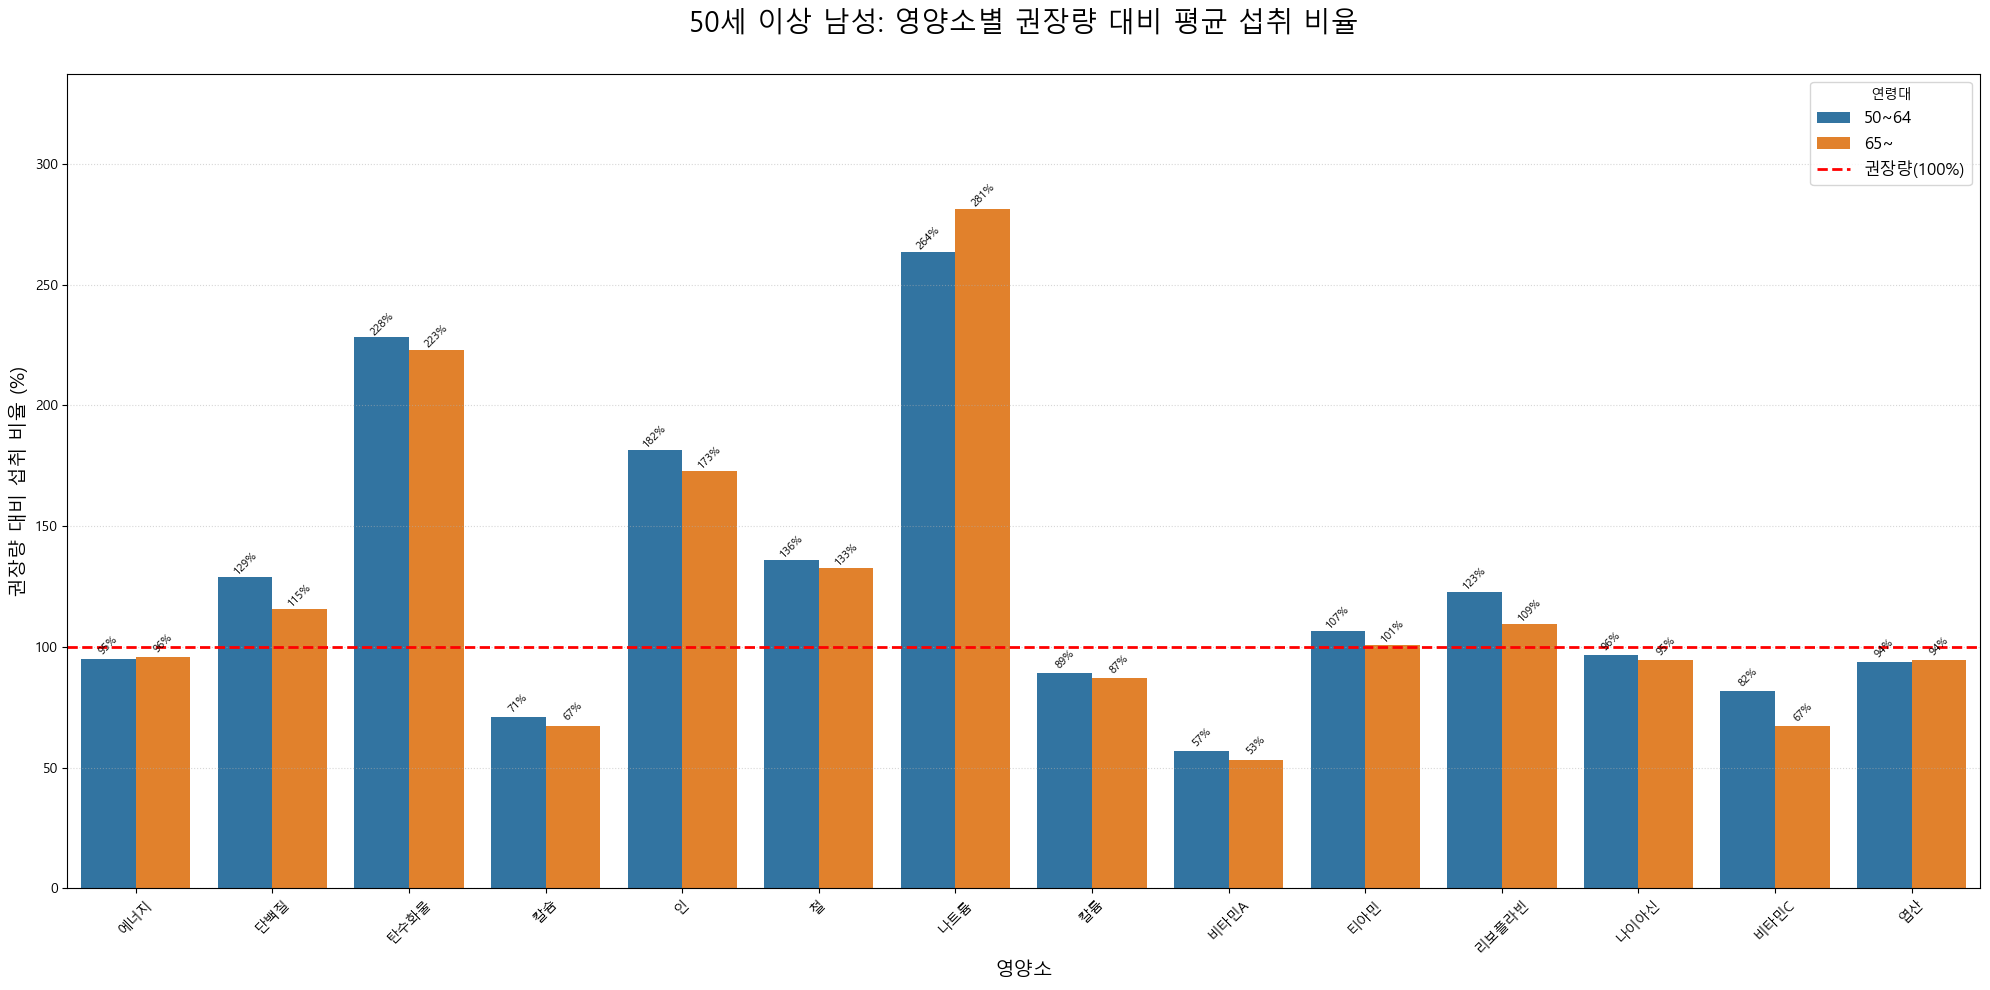

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
df_avg = pd.read_csv('남성 영양소별 평균 섭취량(연령별).csv', index_col=0)
df_req = pd.read_csv('남성 영양소별 권장 섭취량(연령별).csv', index_col=0)

# 2. 분석 대상 연령대 설정
target_ages = ['50~64', '65~']

# 3. 공통으로 존재하는 모든 영양소 리스트 추출 (결측치 제외)
common_nutrients = [col for col in df_avg.columns if col in df_req.columns]

plot_list = []

for age in target_ages:
    for nutrient in common_nutrients:
        try:
            # 데이터 정제 및 숫자 변환
            avg_val = str(df_avg.loc[age, nutrient]).replace(',', '').strip()
            req_val = str(df_req.loc[age, nutrient]).replace(',', '').strip()

            # 값이 비어있거나 데이터가 없는 경우 제외
            if avg_val == '' or req_val == '' or avg_val == 'nan' or req_val == 'nan':
                continue

            ratio = (float(avg_val) / float(req_val)) * 100

            # 그래프 가독성을 위해 이름에서 단위( ) 제거
            clean_name = nutrient.split('(')[0]

            plot_list.append({
                '연령대': age,
                '영양소': clean_name,
                '섭취비율': ratio
            })
        except ValueError:
            # 숫자가 아닌 데이터가 들어있을 경우 건너뜀
            continue

df_plot = pd.DataFrame(plot_list)

# 4. 시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 영양소 개수가 많으므로 그래프 크기를 가로로 길게 설정
plt.figure(figsize=(20, 10))

# 막대 그래프 생성
ax = sns.barplot(data=df_plot, x='영양소', y='섭취비율', hue='연령대')

# 권장량 100% 기준선
plt.axhline(100, color='red', linestyle='--', linewidth=2, label='권장량(100%)')

# 각 막대 위에 비율(%) 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.0f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 10),
                    textcoords = 'offset points',
                    fontsize=8, rotation=45)

plt.title('50세 이상 남성: 영양소별 권장량 대비 평균 섭취 비율', fontsize=20, pad=30)
plt.ylabel('권장량 대비 섭취 비율 (%)', fontsize=14)
plt.xlabel('영양소', fontsize=14)
plt.xticks(rotation=45) # 영양소 이름이 겹치지 않게 회전
plt.grid(axis='y', linestyle=':', alpha=0.5)

# 직관성을 위해 일반 스케일로 유지하되 상단 여백 확보
plt.ylim(0, df_plot['섭취비율'].max() * 1.2)

plt.legend(title='연령대', loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

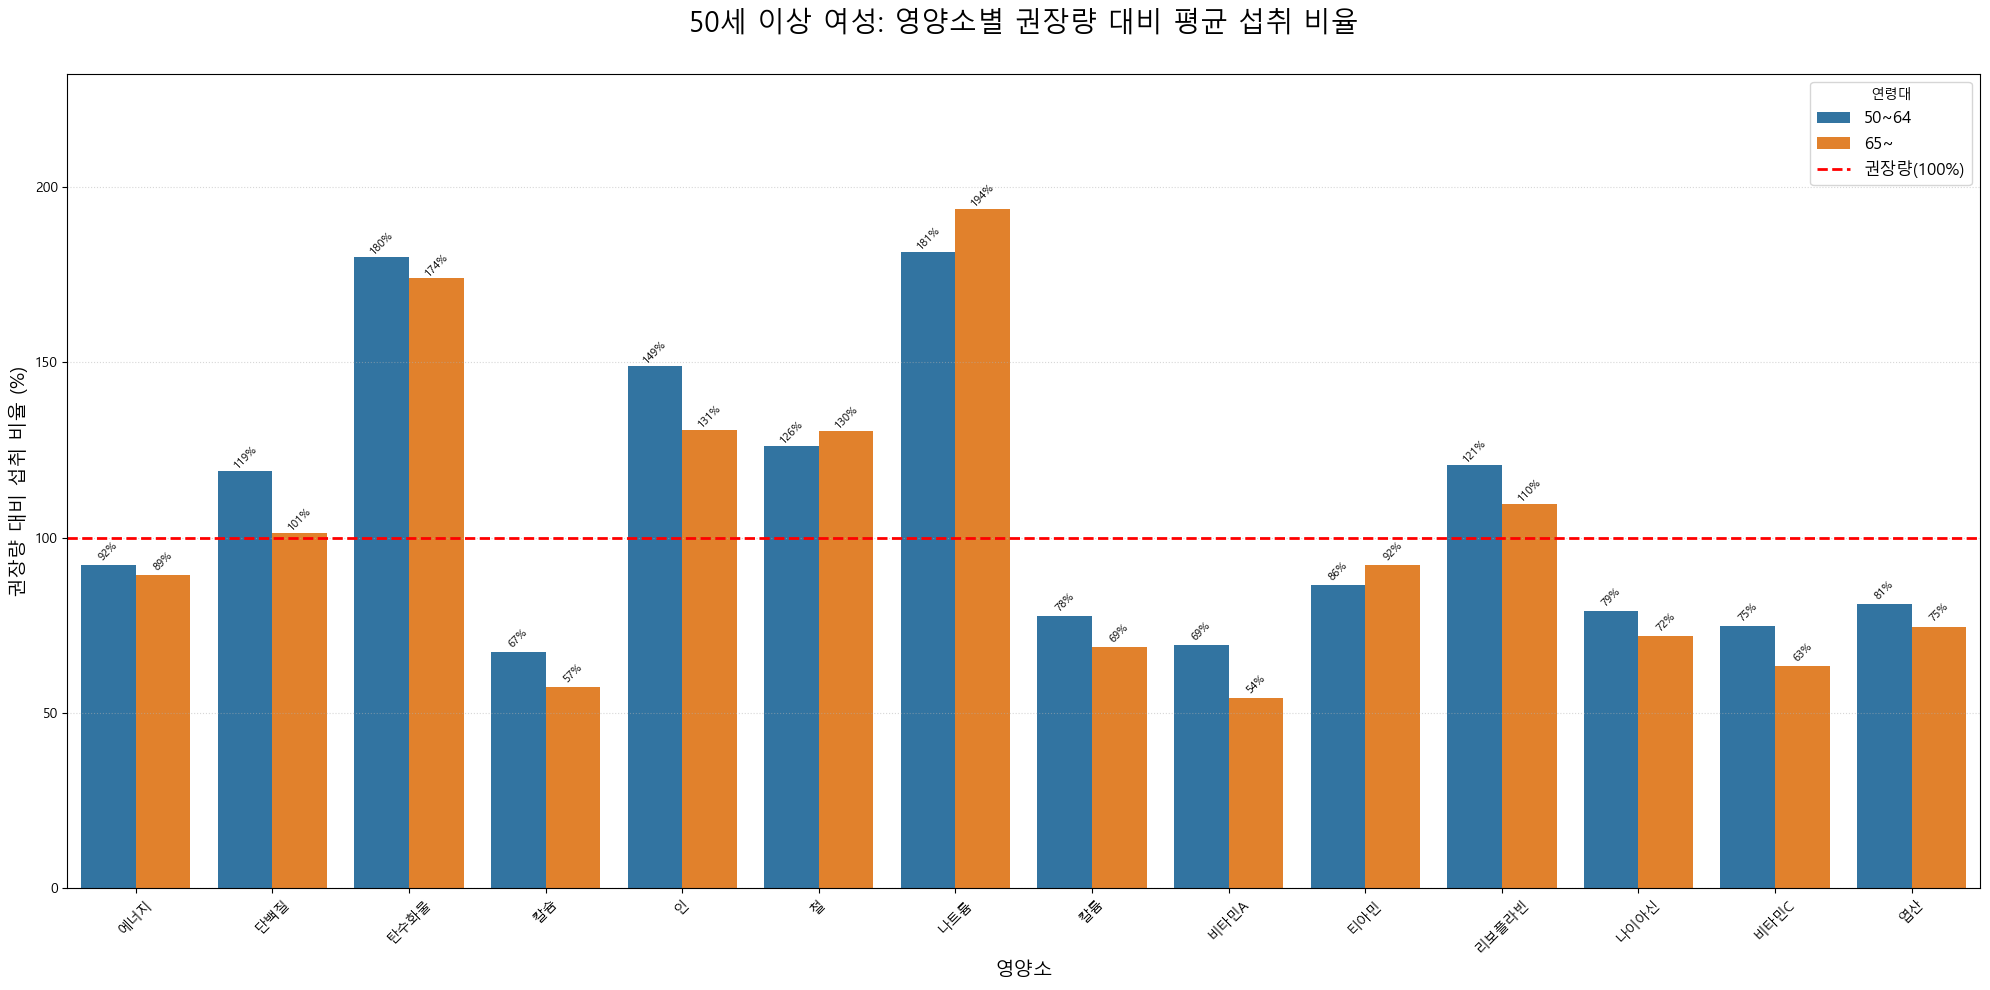

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
df_avg = pd.read_csv('여성 영양소별 평균 섭취량(연령별).csv', index_col=0)
df_req = pd.read_csv('여성 영양소별 권장 섭취량(연령별).csv', index_col=0)

# 2. 분석 대상 연령대 설정
target_ages = ['50~64', '65~']

# 3. 공통으로 존재하는 모든 영양소 리스트 추출 (결측치 제외)
common_nutrients = [col for col in df_avg.columns if col in df_req.columns]

plot_list = []

for age in target_ages:
    for nutrient in common_nutrients:
        try:
            # 데이터 정제 및 숫자 변환
            avg_val = str(df_avg.loc[age, nutrient]).replace(',', '').strip()
            req_val = str(df_req.loc[age, nutrient]).replace(',', '').strip()

            # 값이 비어있거나 데이터가 없는 경우 제외
            if avg_val == '' or req_val == '' or avg_val == 'nan' or req_val == 'nan':
                continue

            ratio = (float(avg_val) / float(req_val)) * 100

            # 그래프 가독성을 위해 이름에서 단위( ) 제거
            clean_name = nutrient.split('(')[0]

            plot_list.append({
                '연령대': age,
                '영양소': clean_name,
                '섭취비율': ratio
            })
        except ValueError:
            # 숫자가 아닌 데이터가 들어있을 경우 건너뜀
            continue

df_plot = pd.DataFrame(plot_list)

# 4. 시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 영양소 개수가 많으므로 그래프 크기를 가로로 길게 설정
plt.figure(figsize=(20, 10))

# 막대 그래프 생성
ax = sns.barplot(data=df_plot, x='영양소', y='섭취비율', hue='연령대')

# 권장량 100% 기준선
plt.axhline(100, color='red', linestyle='--', linewidth=2, label='권장량(100%)')

# 각 막대 위에 비율(%) 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.0f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 10),
                    textcoords = 'offset points',
                    fontsize=8, rotation=45)

plt.title('50세 이상 여성: 영양소별 권장량 대비 평균 섭취 비율', fontsize=20, pad=30)
plt.ylabel('권장량 대비 섭취 비율 (%)', fontsize=14)
plt.xlabel('영양소', fontsize=14)
plt.xticks(rotation=45) # 영양소 이름이 겹치지 않게 회전
plt.grid(axis='y', linestyle=':', alpha=0.5)

# 직관성을 위해 일반 스케일로 유지하되 상단 여백 확보
plt.ylim(0, df_plot['섭취비율'].max() * 1.2)

plt.legend(title='연령대', loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_19324\1784362888.py:33: UserWarning: The palette list has more values (19) than needed (17), which may not be intended.
  sns.lineplot(
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_19324\1784362888.py:33: UserWarning: The palette list has more values (19) than needed (18), which may not be intended.
  sns.lineplot(


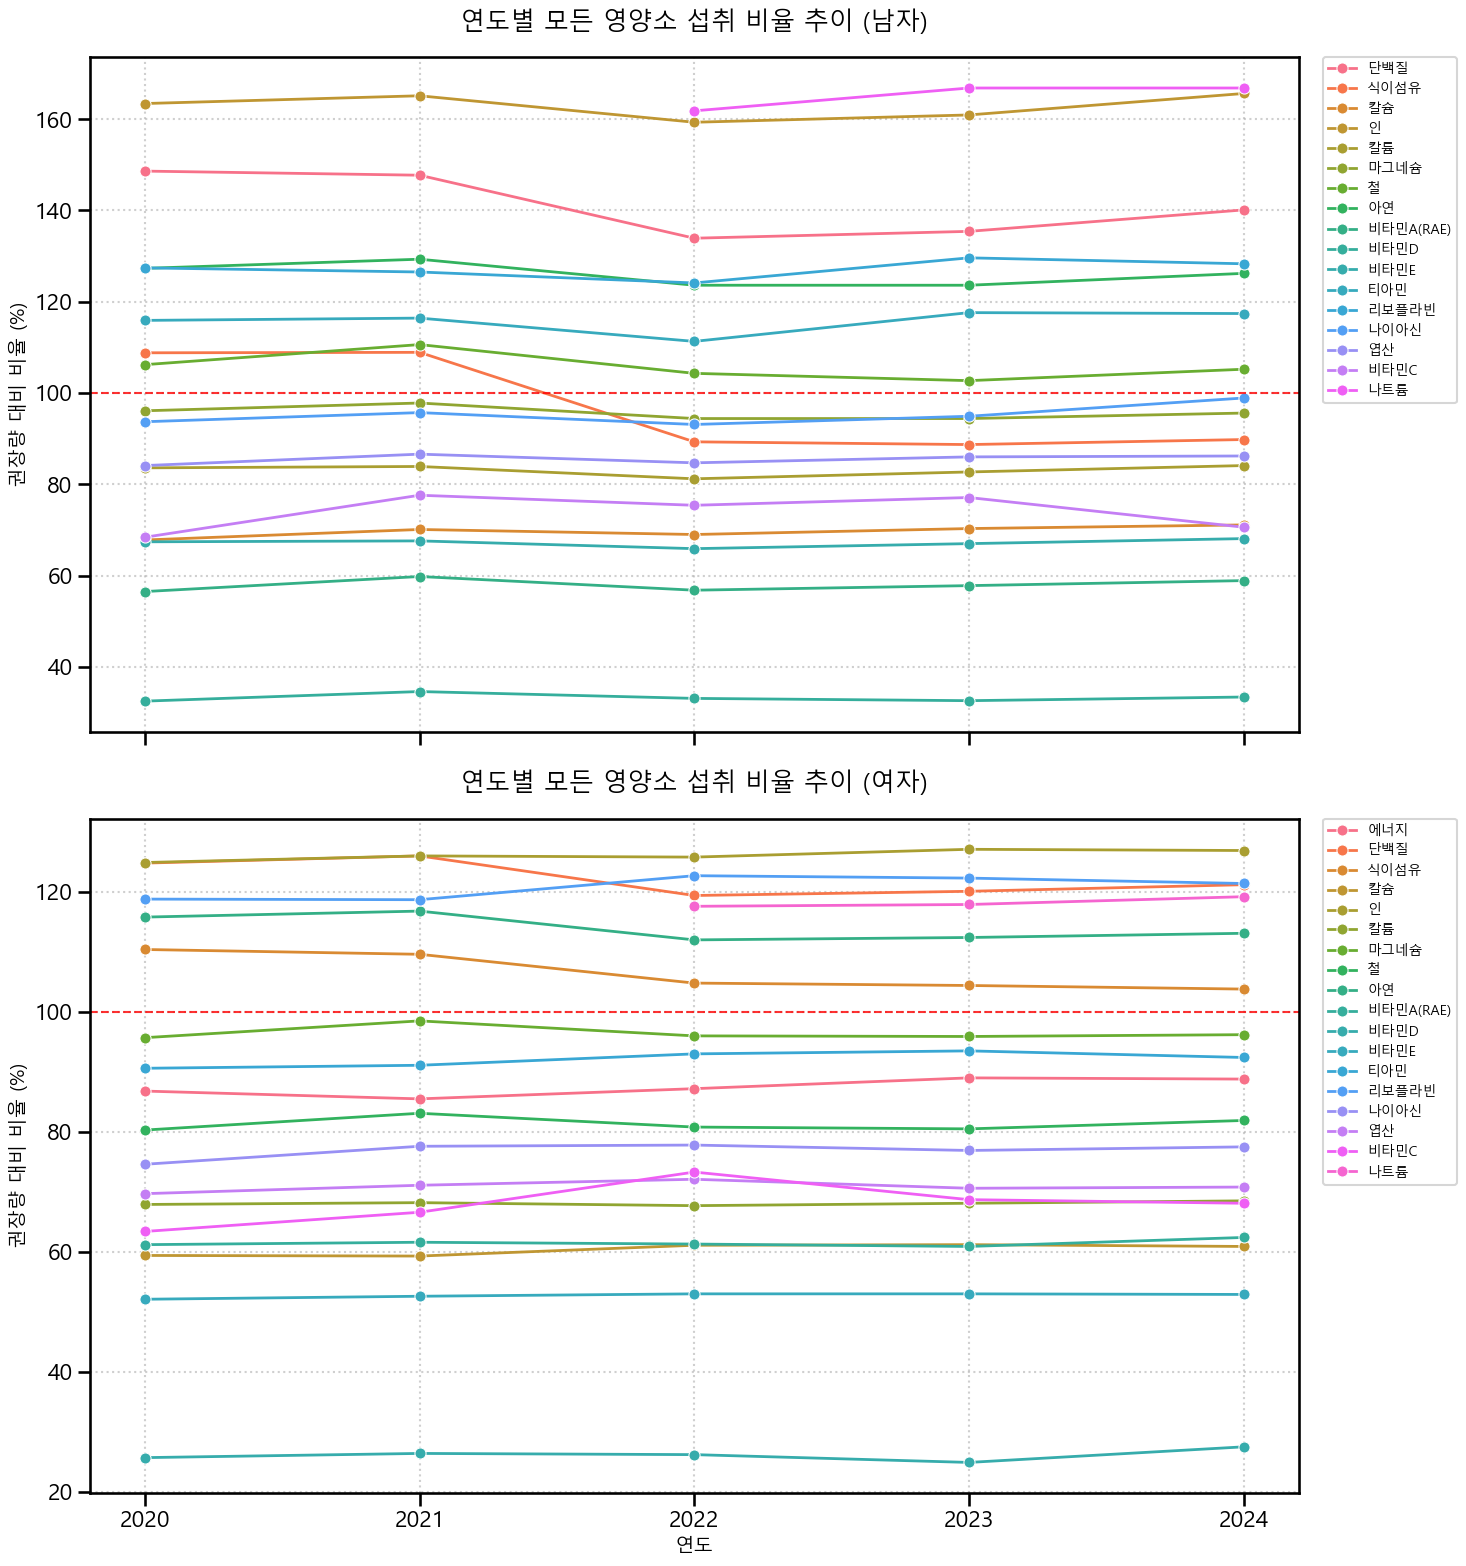

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 전처리
filename = '영양소별_영양소_섭취기준에_대한_섭취비율_추이_조율___1세이상_20260409172322.csv'

# 1행이 메타 정보이므로 header=2로 설정하여 실제 데이터 시작점 지정
df = pd.read_csv(filename,encoding='cp949', header=2)
df.columns = ['성별', '영양소', '2020', '2021', '2022', '2023', '2024']

# 데이터 구조 변경
df_melted = df.melt(id_vars=['성별', '영양소'], var_name='연도', value_name='비율')

# 결측치(-) 처리 및 숫자형 변환
df_melted = df_melted[df_melted['비율'] != '-']
df_melted['비율'] = pd.to_numeric(df_melted['비율'])

# 2. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_context("talk") # 글자 크기를 크게 설정

# 남/여 두 개의 그래프를 위아래로 배치
fig, axes = plt.subplots(2, 1, figsize=(15, 16), sharex=True)

genders = ['남자', '여자']
palette = sns.color_palette("husl", n_colors=len(df['영양소'].unique()))

for i, gender in enumerate(genders):
    gender_data = df_melted[df_melted['성별'] == gender]
    
    # 선 그래프 그리기
    sns.lineplot(
        ax=axes[i],
        data=gender_data,
        x='연도',
        y='비율',
        hue='영양소',
        marker='o',
        linewidth=2,
        markersize=8,
        palette=palette
    )
    
    # 100% 기준선 표시
    axes[i].axhline(100, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    
    axes[i].set_title(f'연도별 모든 영양소 섭취 비율 추이 ({gender})', fontsize=18, pad=20)
    axes[i].set_ylabel('권장량 대비 비율 (%)', fontsize=14)
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    # 범례를 그래프 밖 오른쪽으로 배치
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=10, ncol=1)

plt.xlabel('연도', fontsize=14)
plt.tight_layout()
plt.show()

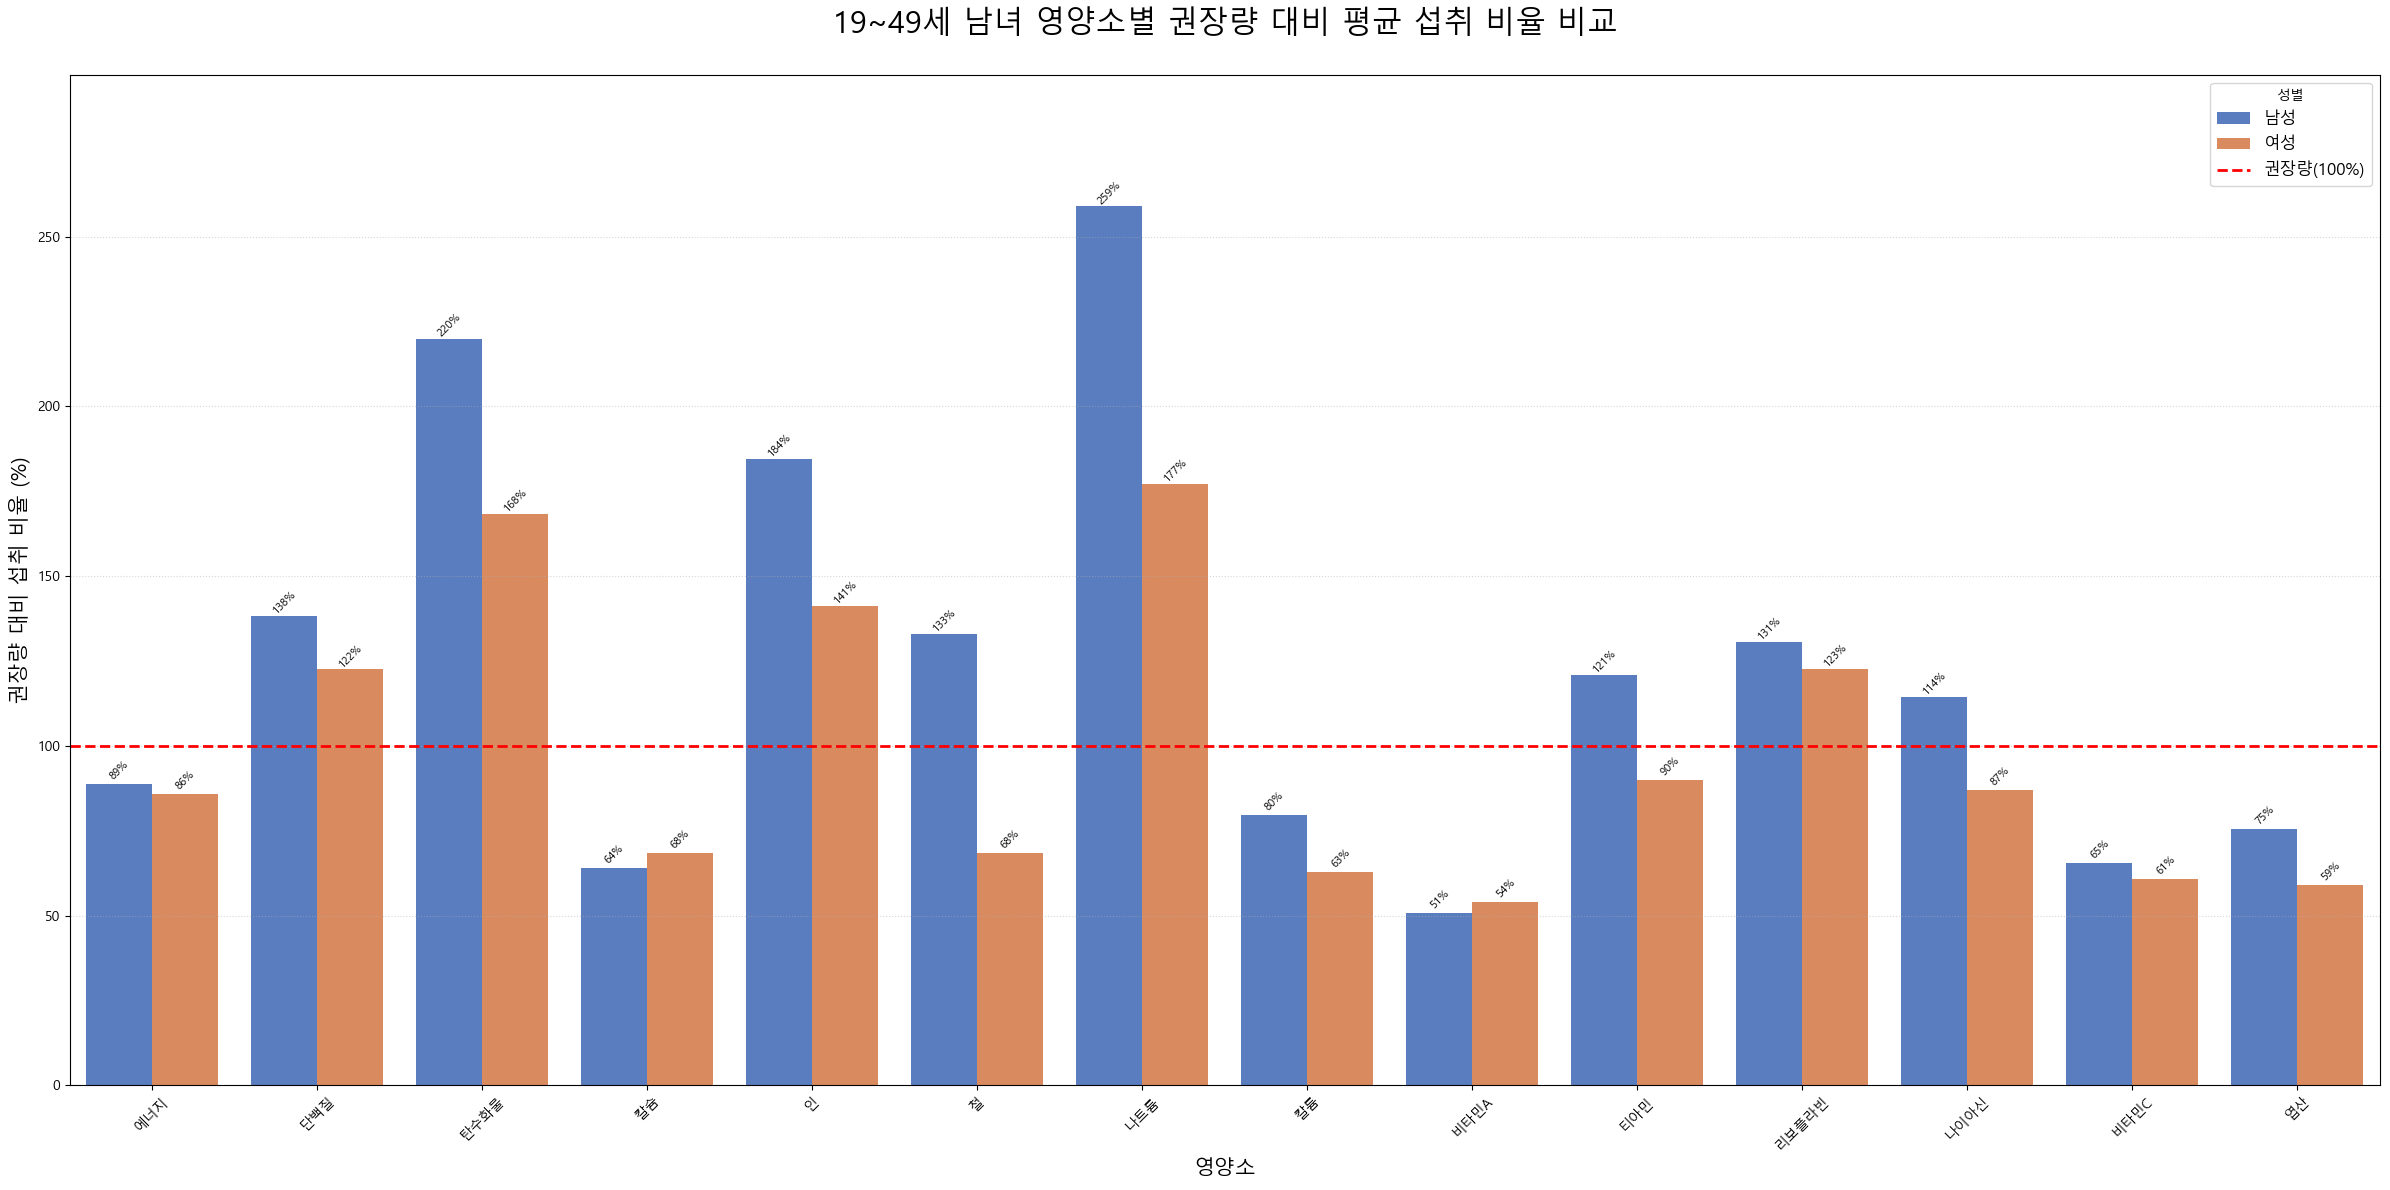

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
files = {
    '남성': ('남성 영양소별 평균 섭취량(연령별).csv', '남성 영양소별 권장 섭취량(연령별).csv'),
    '여성': ('여성 영양소별 평균 섭취량(연령별).csv', '여성 영양소별 권장 섭취량(연령별).csv')
}

target_ages = ['19~29', '30~49']
total_plot_list = []

# 2. 데이터 처리 루프
for gender, (avg_file, req_file) in files.items():
    try:
        df_avg = pd.read_csv(avg_file, index_col=0)
        df_req = pd.read_csv(req_file, index_col=0)
        
        common_nutrients = [col for col in df_avg.columns if col in df_req.columns]

        for nutrient in common_nutrients:
            try:
                # 19~29세와 30~49세 데이터 합산 및 전처리
                avg_val = 0
                req_val = 0
                valid_data = True

                for age_group in target_ages:
                    a_val = str(df_avg.loc[age_group, nutrient]).replace(',', '').strip()
                    r_val = str(df_req.loc[age_group, nutrient]).replace(',', '').strip()
                    
                    if a_val in ['nan', '0', ''] or r_val in ['nan', '0', '']:
                        valid_data = False
                        break
                    
                    avg_val += float(a_val)
                    req_val += float(r_val)

                if not valid_data or req_val == 0:
                    continue

                # 비율 계산
                ratio = (avg_val / req_val) * 100
                clean_name = nutrient.split('(')[0]

                total_plot_list.append({
                    '성별': gender,
                    '영양소': clean_name,
                    '섭취비율': ratio
                })
            except Exception:
                continue
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {gender} 데이터 확인 필요")

# 데이터프레임 변환
df_plot = pd.DataFrame(total_plot_list)

# 3. 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(24, 12))

# 막대 그래프 생성 (hue를 '성별'로 설정)
ax = sns.barplot(data=df_plot, x='영양소', y='섭취비율', hue='성별', palette='muted')

# 권장량 100% 기준선
plt.axhline(100, color='red', linestyle='--', linewidth=2, label='권장량(100%)')

# 각 막대 위에 비율(%) 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.0f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=8, rotation=45)

plt.title('19~49세 남녀 영양소별 권장량 대비 평균 섭취 비율 비교', fontsize=22, pad=30)
plt.ylabel('권장량 대비 섭취 비율 (%)', fontsize=15)
plt.xlabel('영양소', fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Y축 범위 조정
plt.ylim(0, df_plot['섭취비율'].max() * 1.15)

plt.legend(title='성별', loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

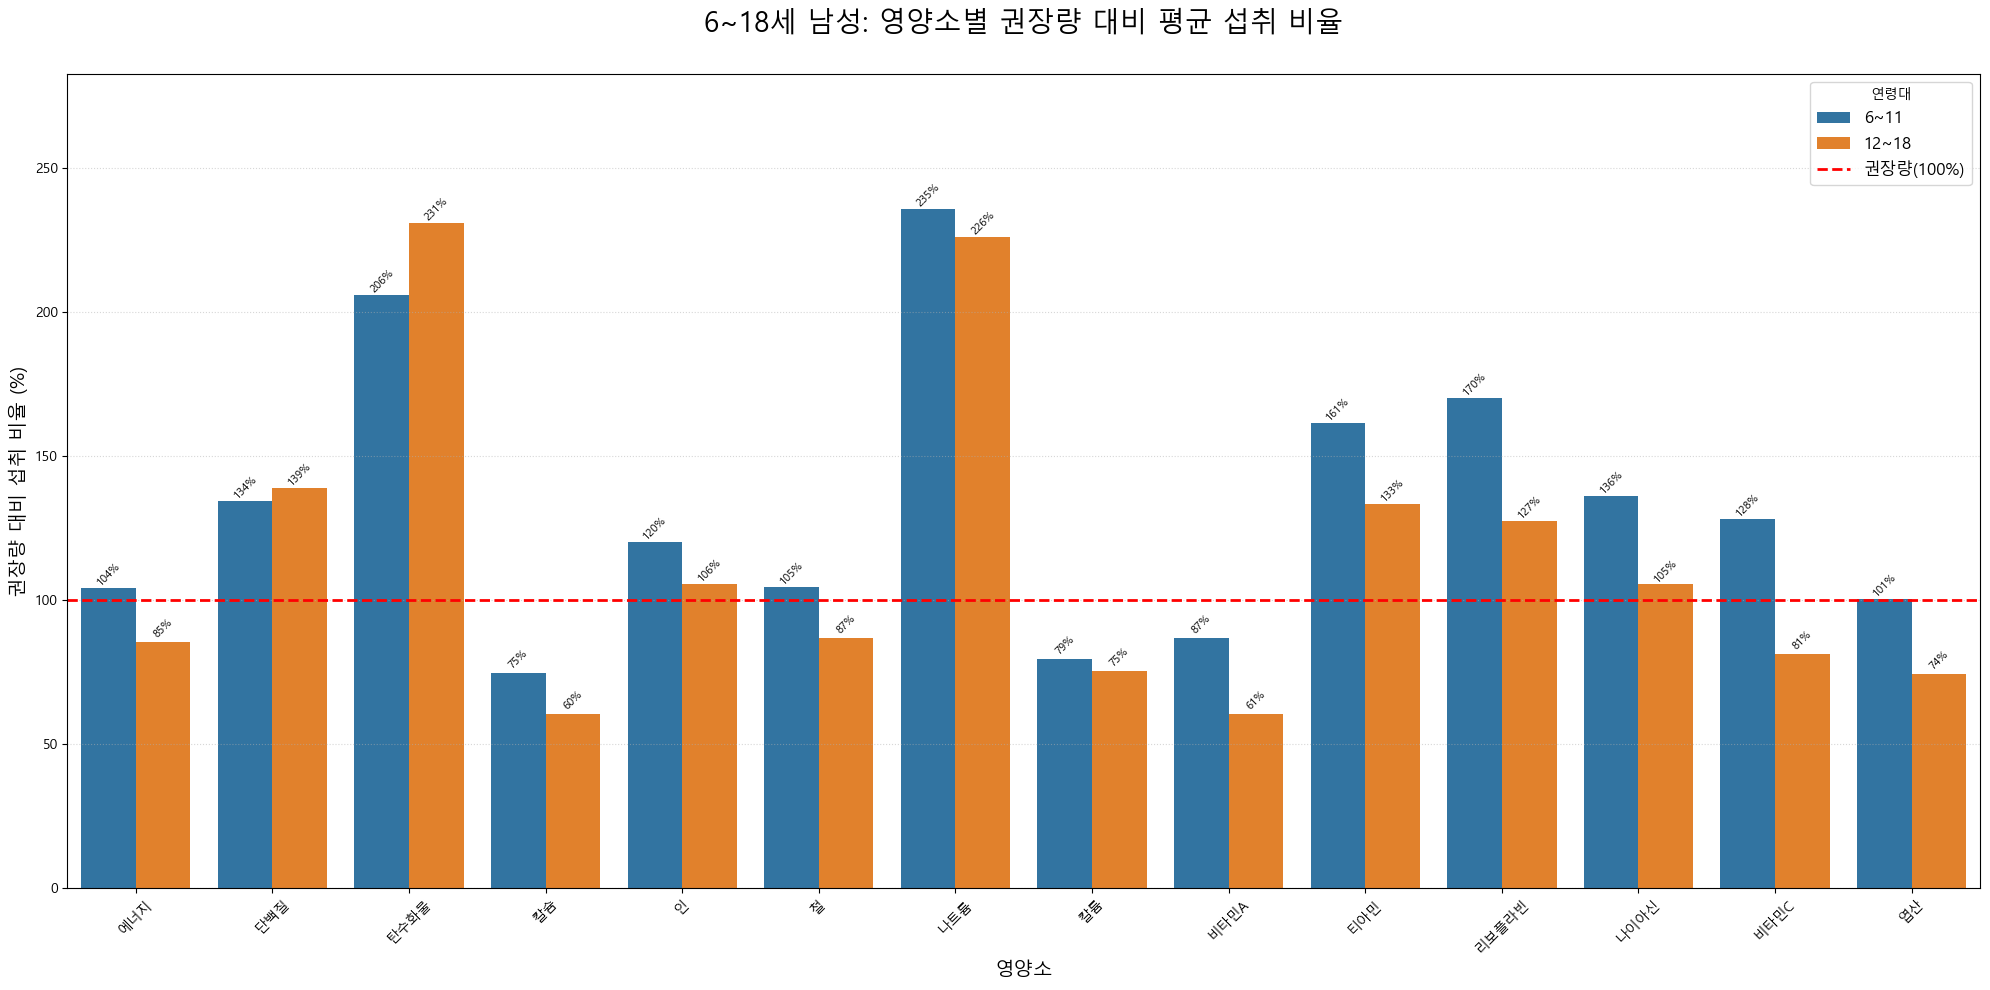

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
df_avg = pd.read_csv('남성 영양소별 평균 섭취량(연령별).csv', index_col=0)
df_req = pd.read_csv('남성 영양소별 권장 섭취량(연령별).csv', index_col=0)

# 2. 분석 대상 연령대 설정
target_ages = ['6~11', '12~18']

# 3. 공통으로 존재하는 모든 영양소 리스트 추출 (결측치 제외)
common_nutrients = [col for col in df_avg.columns if col in df_req.columns]

plot_list = []

for age in target_ages:
    for nutrient in common_nutrients:
        try:
            # 데이터 정제 및 숫자 변환
            avg_val = str(df_avg.loc[age, nutrient]).replace(',', '').strip()
            req_val = str(df_req.loc[age, nutrient]).replace(',', '').strip()

            # 값이 비어있거나 데이터가 없는 경우 제외
            if avg_val == '' or req_val == '' or avg_val == 'nan' or req_val == 'nan':
                continue

            ratio = (float(avg_val) / float(req_val)) * 100

            # 그래프 가독성을 위해 이름에서 단위( ) 제거
            clean_name = nutrient.split('(')[0]

            plot_list.append({
                '연령대': age,
                '영양소': clean_name,
                '섭취비율': ratio
            })
        except ValueError:
            # 숫자가 아닌 데이터가 들어있을 경우 건너뜀
            continue

df_plot = pd.DataFrame(plot_list)

# 4. 시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 영양소 개수가 많으므로 그래프 크기를 가로로 길게 설정
plt.figure(figsize=(20, 10))

# 막대 그래프 생성
ax = sns.barplot(data=df_plot, x='영양소', y='섭취비율', hue='연령대')

# 권장량 100% 기준선
plt.axhline(100, color='red', linestyle='--', linewidth=2, label='권장량(100%)')

# 각 막대 위에 비율(%) 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.0f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 10),
                    textcoords = 'offset points',
                    fontsize=8, rotation=45)

plt.title('6~18세 남성: 영양소별 권장량 대비 평균 섭취 비율', fontsize=20, pad=30)
plt.ylabel('권장량 대비 섭취 비율 (%)', fontsize=14)
plt.xlabel('영양소', fontsize=14)
plt.xticks(rotation=45) # 영양소 이름이 겹치지 않게 회전
plt.grid(axis='y', linestyle=':', alpha=0.5)

# 직관성을 위해 일반 스케일로 유지하되 상단 여백 확보
plt.ylim(0, df_plot['섭취비율'].max() * 1.2)

plt.legend(title='연령대', loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

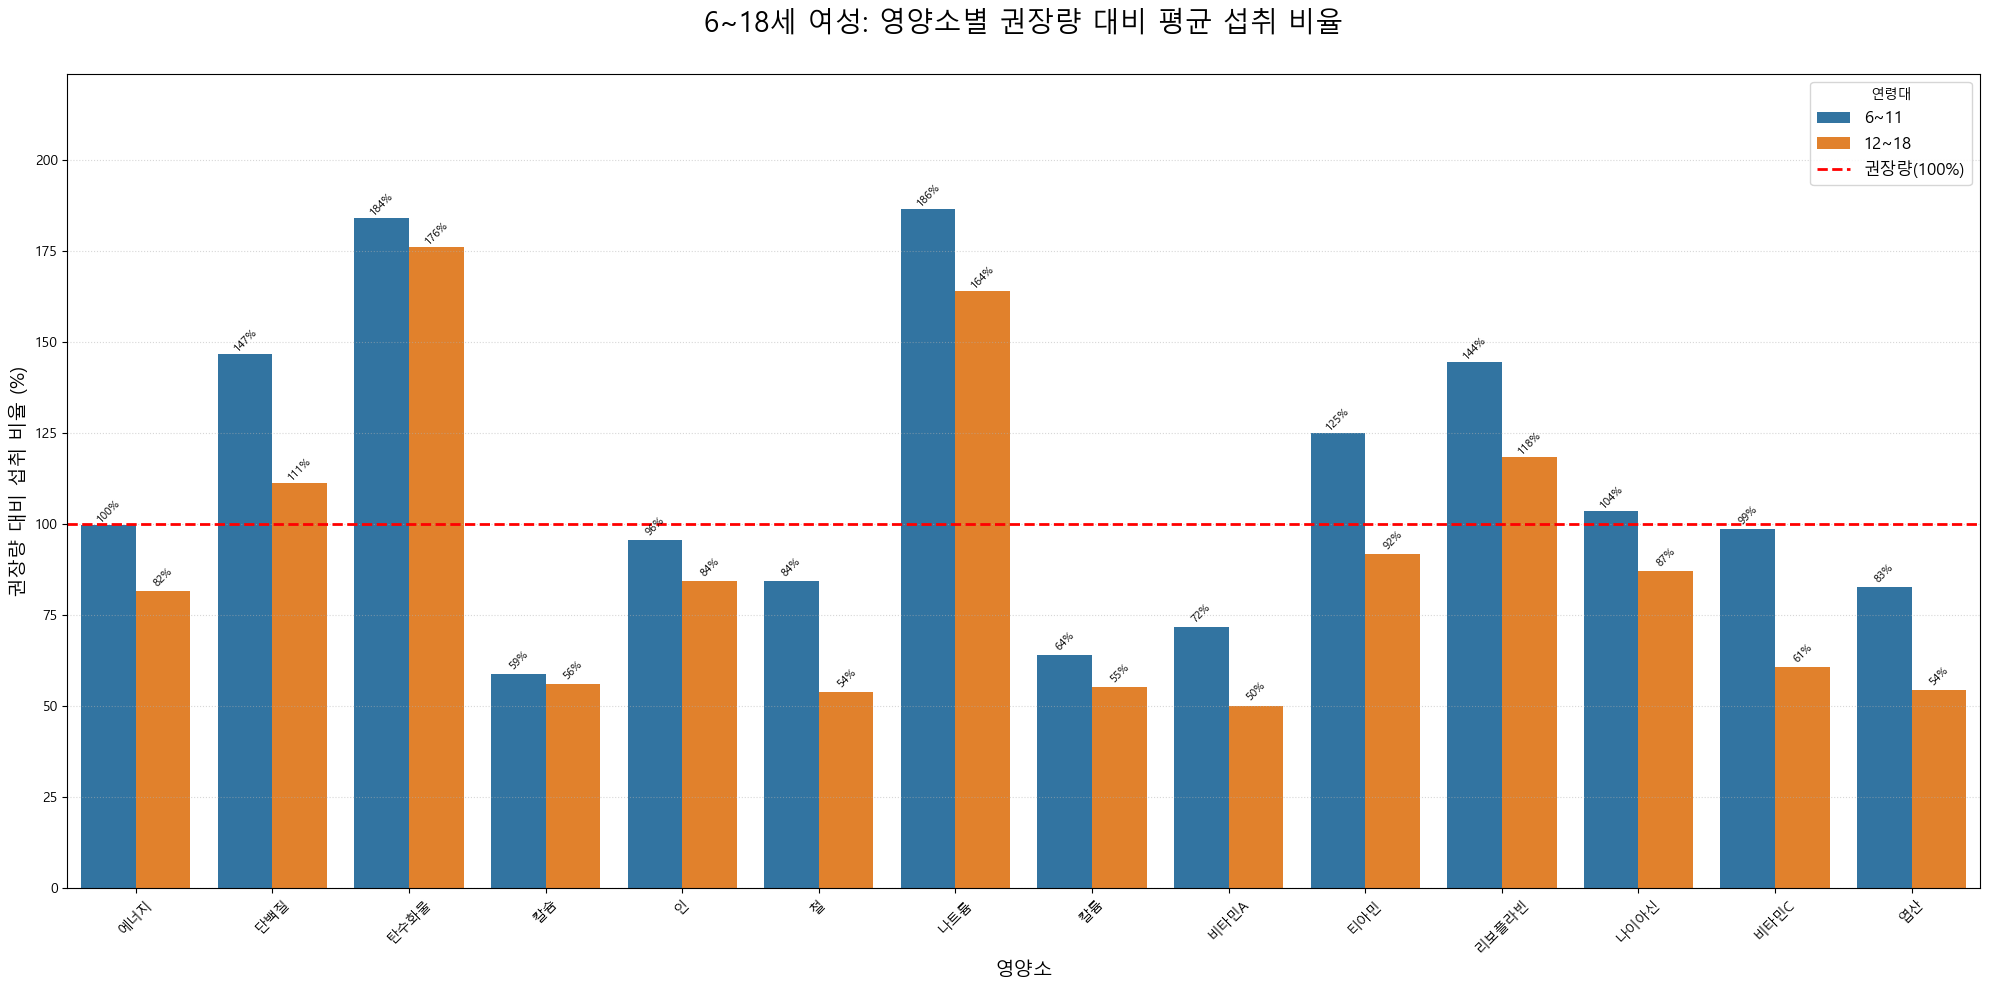

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
df_avg = pd.read_csv('여성 영양소별 평균 섭취량(연령별).csv', index_col=0)
df_req = pd.read_csv('여성 영양소별 권장 섭취량(연령별).csv', index_col=0)

# 2. 분석 대상 연령대 설정
target_ages = ['6~11', '12~18']

# 3. 공통으로 존재하는 모든 영양소 리스트 추출 (결측치 제외)
common_nutrients = [col for col in df_avg.columns if col in df_req.columns]

plot_list = []

for age in target_ages:
    for nutrient in common_nutrients:
        try:
            # 데이터 정제 및 숫자 변환
            avg_val = str(df_avg.loc[age, nutrient]).replace(',', '').strip()
            req_val = str(df_req.loc[age, nutrient]).replace(',', '').strip()

            # 값이 비어있거나 데이터가 없는 경우 제외
            if avg_val == '' or req_val == '' or avg_val == 'nan' or req_val == 'nan':
                continue

            ratio = (float(avg_val) / float(req_val)) * 100

            # 그래프 가독성을 위해 이름에서 단위( ) 제거
            clean_name = nutrient.split('(')[0]

            plot_list.append({
                '연령대': age,
                '영양소': clean_name,
                '섭취비율': ratio
            })
        except ValueError:
            # 숫자가 아닌 데이터가 들어있을 경우 건너뜀
            continue

df_plot = pd.DataFrame(plot_list)

# 4. 시각화
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 영양소 개수가 많으므로 그래프 크기를 가로로 길게 설정
plt.figure(figsize=(20, 10))

# 막대 그래프 생성
ax = sns.barplot(data=df_plot, x='영양소', y='섭취비율', hue='연령대')

# 권장량 100% 기준선
plt.axhline(100, color='red', linestyle='--', linewidth=2, label='권장량(100%)')

# 각 막대 위에 비율(%) 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.0f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 10),
                    textcoords = 'offset points',
                    fontsize=8, rotation=45)

plt.title('6~18세 여성: 영양소별 권장량 대비 평균 섭취 비율', fontsize=20, pad=30)
plt.ylabel('권장량 대비 섭취 비율 (%)', fontsize=14)
plt.xlabel('영양소', fontsize=14)
plt.xticks(rotation=45) # 영양소 이름이 겹치지 않게 회전
plt.grid(axis='y', linestyle=':', alpha=0.5)

# 직관성을 위해 일반 스케일로 유지하되 상단 여백 확보
plt.ylim(0, df_plot['섭취비율'].max() * 1.2)

plt.legend(title='연령대', loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

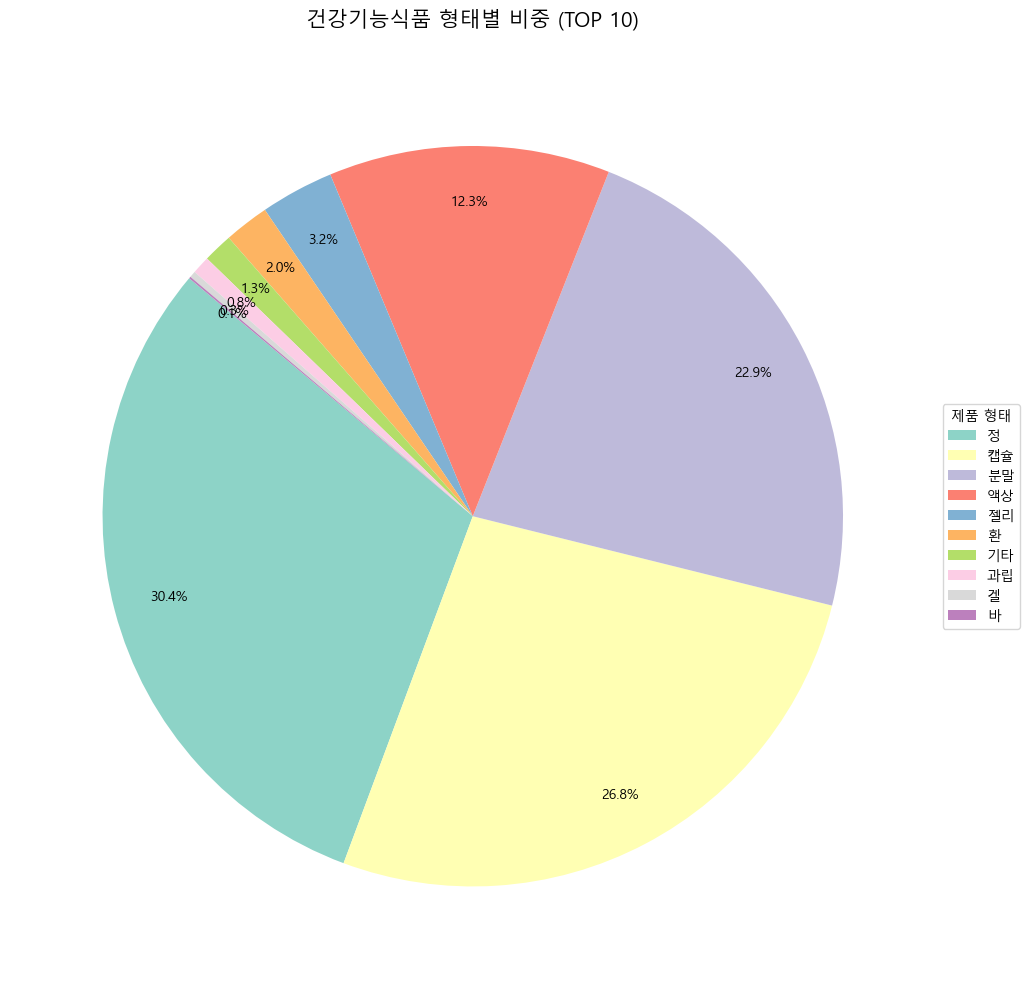

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('health_foods.csv')

# 전처리
df['PRDT_SHAP_CD_NM'] = df['PRDT_SHAP_CD_NM'].str.strip().fillna('미분류')
df.loc[df['PRDT_SHAP_CD_NM'].str.contains('기타'), 'PRDT_SHAP_CD_NM'] = '기타'

plt.rcParams['font.family'] = 'Malgun Gothic'

shape_counts = df['PRDT_SHAP_CD_NM'].value_counts()
top_n = 10
plot_data = shape_counts.head(top_n)

plt.figure(figsize=(12, 10)) # 가로 길이를 늘려 범례 공간 확보

# 파이차트 설정 (labels를 제거하고 퍼센트 위치 조정)
patches, texts, autotexts = plt.pie(
    plot_data, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Set3.colors,
    pctdistance=0.85, # 퍼센트 글자를 조금 바깥으로
    labeldistance=1.1
)

# 퍼센트 글자 크기 조절
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)

# 범례를 우측 상단에 배치 (라벨이 겹치지 않게 함)
plt.legend(patches, plot_data.index, title="제품 형태", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('건강기능식품 형태별 비중 (TOP 10)', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

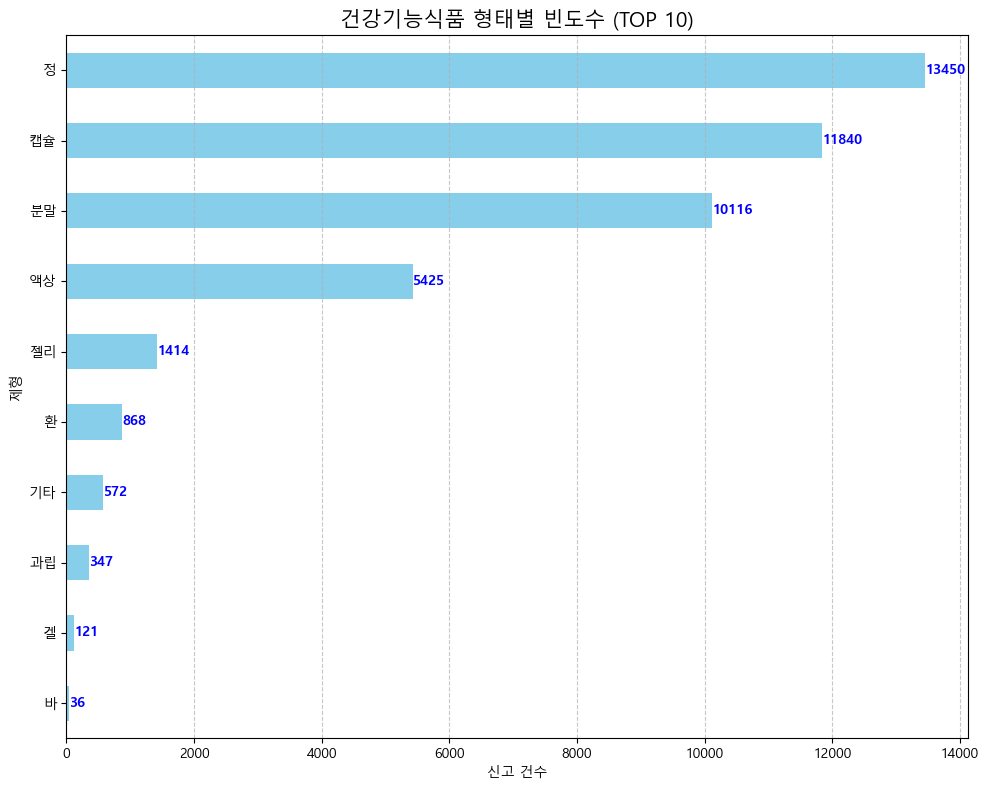

In [6]:
plt.figure(figsize=(10, 8))
plot_data.sort_values().plot(kind='barh', color='skyblue')

plt.title('건강기능식품 형태별 빈도수 (TOP 10)', fontsize=15)
plt.xlabel('신고 건수')
plt.ylabel('제형')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 막대 끝에 숫자 표시
for i, v in enumerate(plot_data.sort_values()):
    plt.text(v + 10, i, str(v), color='blue', fontweight='bold', va='center')

plt.tight_layout()
plt.show()

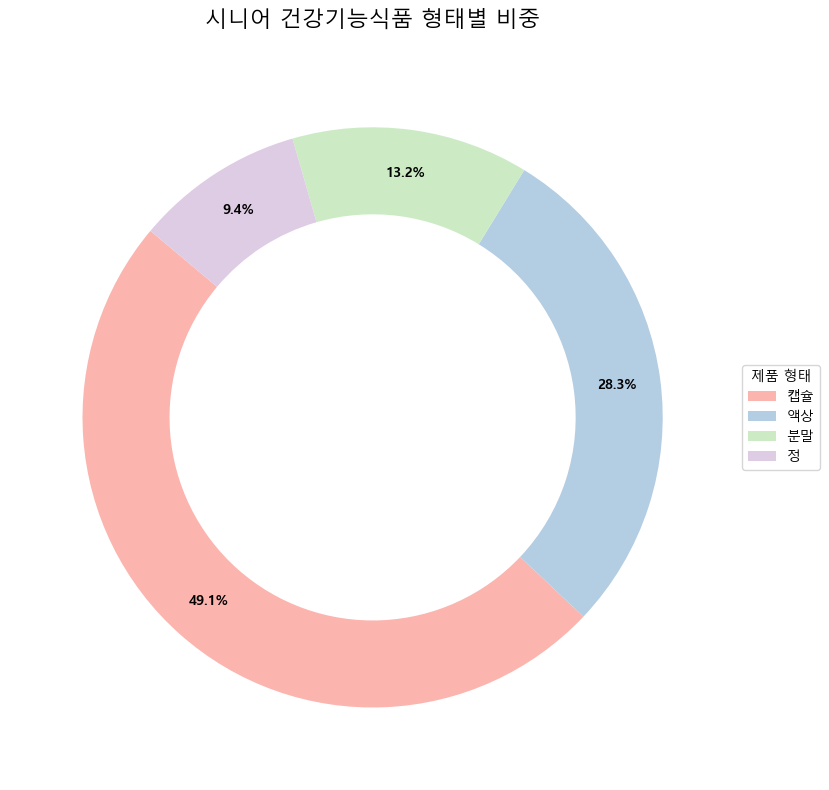

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('senior_형태.csv', encoding='cp949')

# 2. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 3. 데이터 전처리
# 양끝 공백 제거 및 결측치 처리
df['PRDT_SHAP_CD_NM'] = df['PRDT_SHAP_CD_NM'].str.strip().fillna('미분류')

# 4. 형태별 빈도수 계산
shape_counts = df['PRDT_SHAP_CD_NM'].value_counts()

# 5. 시각화 (도넛 차트)
plt.figure(figsize=(10, 8))

# 파이차트 그리기 (글자 겹침 방지를 위해 범례 사용)
patches, texts, autotexts = plt.pie(
    shape_counts, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Pastel1.colors,
    pctdistance=0.85,  # 퍼센트 수치 위치
    wedgeprops={'width': 0.3}  # 도넛 두께 (0.3이면 도넛 형태가 됨)
)

# 퍼센트 글자 크기 및 색상 조절
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# 범례 설정 (우측 중앙에 배치하여 라벨 겹침 원천 차단)
plt.legend(
    patches, 
    shape_counts.index, 
    title="제품 형태", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('시니어 건강기능식품 형태별 비중', fontsize=16, pad=20)
plt.tight_layout()

# 그래프 표시
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9952\3584809510.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='사용 빈도', y='원재료', data=top_materials, palette='viridis')


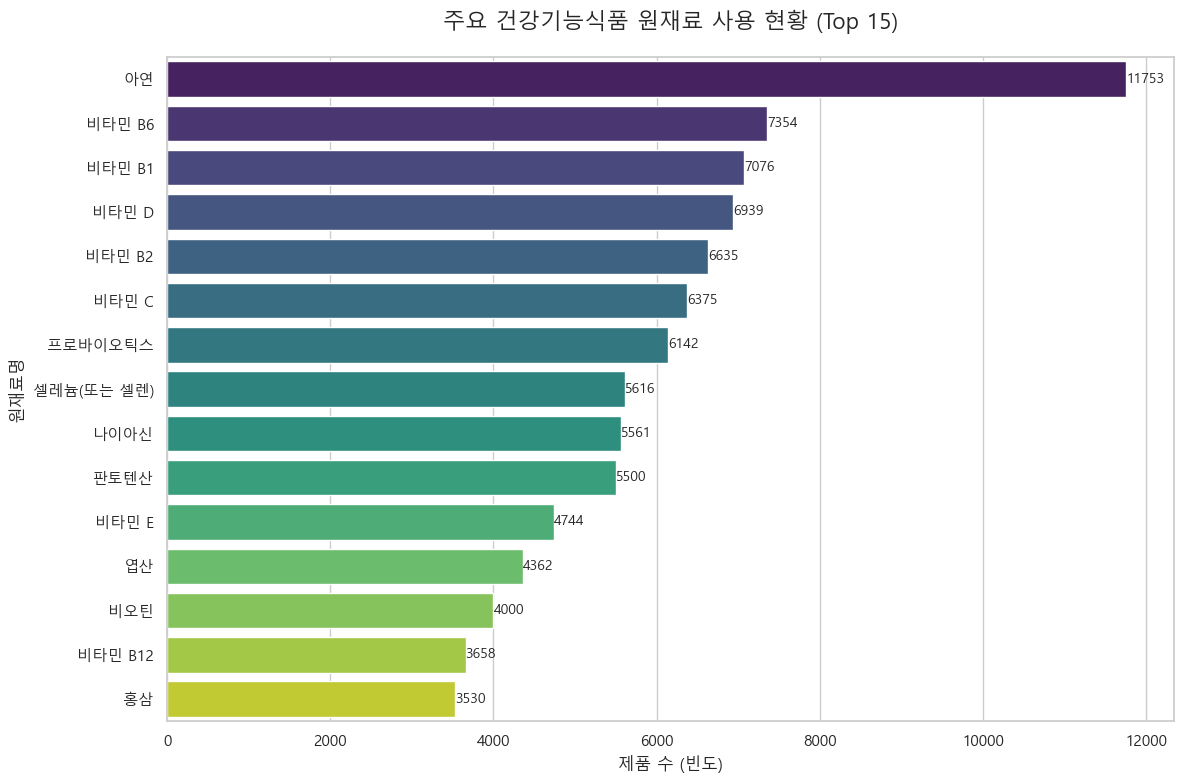

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. 데이터 불러오기
df = pd.read_csv('health_foods_02.csv')

# 2. 원재료 데이터 전처리
# 결측치 제거 후 모든 원재료를 하나의 리스트로 통합
raw_materials = df['RAWMTRL_NM'].dropna().str.split(',')
all_materials = [item.strip() for sublist in raw_materials for item in sublist]

# 3. 원재료 빈도 계산
material_counts = Counter(all_materials)
# 상위 15개 항목 추출
top_materials = pd.DataFrame(material_counts.most_common(15), columns=['원재료', '사용 빈도'])

# 4. 시각화
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' 

ax = sns.barplot(x='사용 빈도', y='원재료', data=top_materials, palette='viridis')

# 그래프 디테일 설정
plt.title('주요 건강기능식품 원재료 사용 현황 (Top 15)', fontsize=16, pad=20)
plt.xlabel('제품 수 (빈도)', fontsize=12)
plt.ylabel('원재료명', fontsize=12)

# 막대 끝에 숫자 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width() + 0.1, p.get_y() + p.get_height()/2), 
                va='center', fontsize=10)

plt.tight_layout()
plt.show()

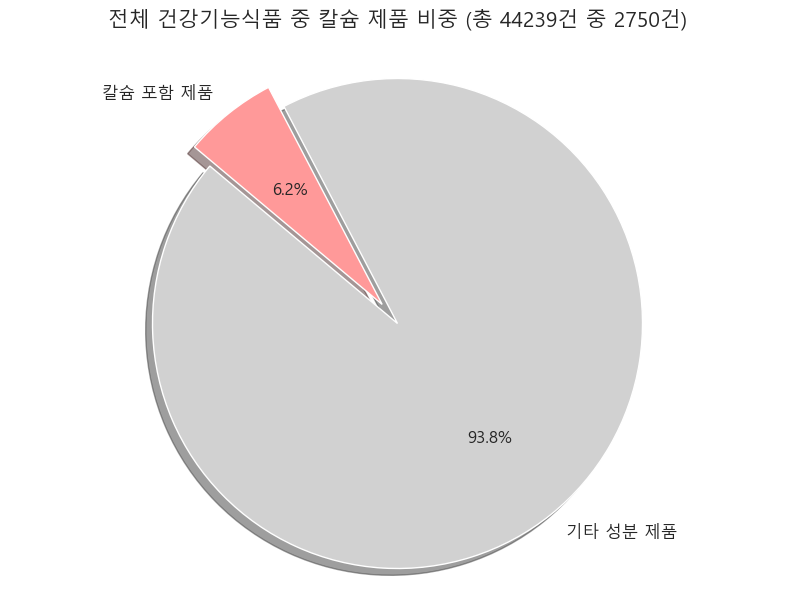

전체 제품 수: 44239개
칼슘 포함 제품 수: 2750개
전체 대비 비중: 6.22%


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('health_foods_02.csv')

# 2. '칼슘' 포함 여부 확인
df['has_calcium'] = df['RAWMTRL_NM'].fillna('').str.contains('칼슘')

# 3. 비중 계산
counts = df['has_calcium'].value_counts()
labels = ['기타 성분 제품', '칼슘 포함 제품']
sizes = [counts[False], counts[True]]
colors = ['#d1d1d1', '#ff9999'] # 칼슘 제품을 강조하기 위한 색상 구성
explode = (0, 0.1)  # 칼슘 제품 슬라이스를 약간 분리

# 4. 시각화 (Pie Chart)
plt.figure(figsize=(10, 7))
plt.rcParams['font.family'] = 'Malgun Gothic'

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=140, colors=colors, textprops={'fontsize': 12})

plt.title(f'전체 건강기능식품 중 칼슘 제품 비중 (총 {len(df)}건 중 {counts[True]}건)', 
          fontsize=15, pad=20)

plt.axis('equal') # 원형 유지
plt.show()

# 5. 통계 요약 출력
print(f"전체 제품 수: {len(df)}개")
print(f"칼슘 포함 제품 수: {counts[True]}개")
print(f"전체 대비 비중: {(counts[True]/len(df))*100:.2f}%")

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9952\2130033525.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='비중(%)', y='영양소', data=df_nutrients, palette=colors)


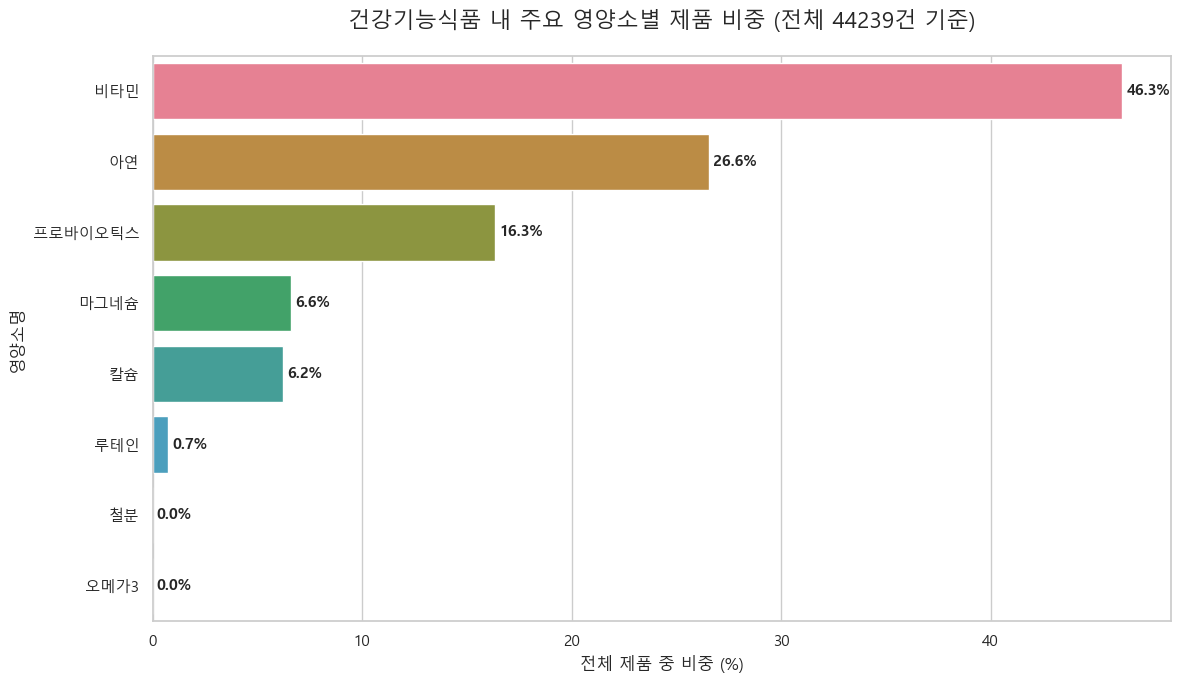

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
df = pd.read_csv('health_foods.csv')

# 2. 분석할 주요 영양소 키워드 설정
nutrients = ['비타민', '칼슘', '아연', '철분', '마그네슘', '프로바이오틱스', '오메가3', '루테인']

# 3. 각 영양소별 포함 제품 수 집계
nutrient_counts = {}
total_products = len(df)

for nutrient in nutrients:
    # 원재료명(RAWMTRL_NM) 컬럼에서 해당 키워드가 포함된 행의 개수를 셈
    count = df['RAWMTRL_NM'].fillna('').str.contains(nutrient).sum()
    nutrient_counts[nutrient] = (count / total_products) * 100

# 4. 데이터프레임 변환 및 정렬
df_nutrients = pd.DataFrame(list(nutrient_counts.items()), columns=['영양소', '비중(%)'])
df_nutrients = df_nutrients.sort_values(by='비중(%)', ascending=False)

# 5. 시각화
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 막대 그래프 생성
colors = sns.color_palette("husl", len(nutrients))
ax = sns.barplot(x='비중(%)', y='영양소', data=df_nutrients, palette=colors)

# 그래프 디테일 설정
plt.title(f'건강기능식품 내 주요 영양소별 제품 비중 (전체 {total_products}건 기준)', fontsize=16, pad=20)
plt.xlabel('전체 제품 중 비중 (%)', fontsize=12)
plt.ylabel('영양소명', fontsize=12)

# 막대 끝에 퍼센트 수치 표시
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.2, p.get_y() + p.get_height()/2, 
             f'{width:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9952\3118259295.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='제형', y='제품 수', data=df_shape, palette='Set2')


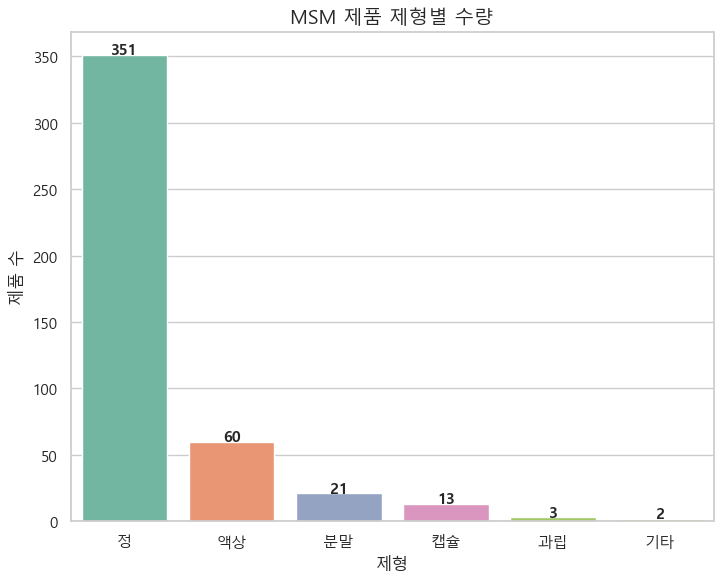

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
df = pd.read_csv('MSM제품_제형.csv', encoding = 'cp949')

# 2. 제형별 빈도 계산
# PRDT_SHAP_CD_NM 컬럼의 데이터 분포
shape_counts = df['PRDT_SHAP_CD_NM'].value_counts()
df_shape = shape_counts.reset_index()
df_shape.columns = ['제형', '제품 수']

# 3. 시각화 설정
plt.figure(figsize=(14, 6))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.subplot(1, 2, 1)
sns.barplot(x='제형', y='제품 수', data=df_shape, palette='Set2')
plt.title('MSM 제품 제형별 수량', fontsize=14)
plt.xlabel('제형', fontsize=12)
plt.ylabel('제품 수', fontsize=12)

# 막대 위에 숫자 표시
for i, val in enumerate(df_shape['제품 수']):
    plt.text(i, val + 0.5, str(val), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9952\4016862171.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='제품 수', y='제형', data=shape_counts, palette='coolwarm')


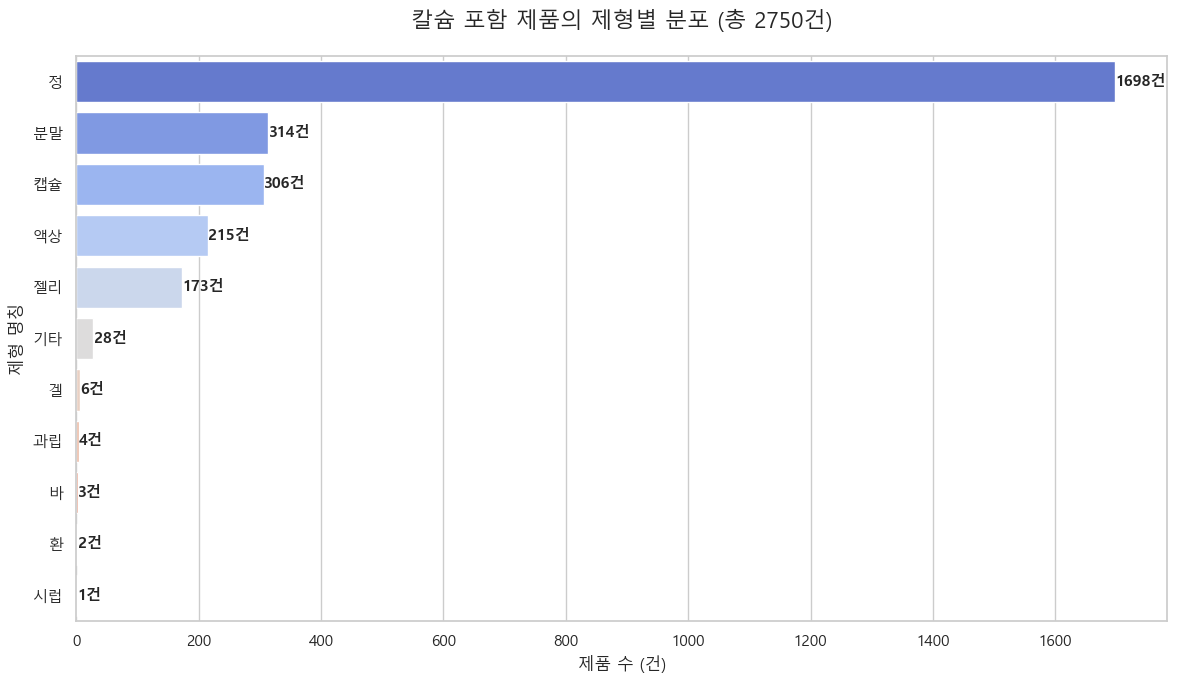

칼슘 성분이 포함된 전체 제품 수: 2750개
------------------------------
제형  제품 수
 정  1698
분말   314
캡슐   306
액상   215
젤리   173
기타    28
 겔     6
과립     4
 바     3
 환     2
시럽     1


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
df = pd.read_csv('health_foods.csv')

# 2. '칼슘' 성분이 포함된 제품 필터링
# 원재료명(RAWMTRL_NM)에서 '칼슘' 키워드를 찾음
calcium_df = df[df['RAWMTRL_NM'].fillna('').str.contains('칼슘')].copy()

# 3. 제형(PRDT_SHAP_CD_NM)별 빈도 계산
shape_counts = calcium_df['PRDT_SHAP_CD_NM'].value_counts().reset_index()
shape_counts.columns = ['제형', '제품 수']

# 4. 시각화
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 또는 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 막대 그래프 생성
ax = sns.barplot(x='제품 수', y='제형', data=shape_counts, palette='coolwarm')

# 그래프 디테일 설정
plt.title(f'칼슘 포함 제품의 제형별 분포 (총 {len(calcium_df)}건)', fontsize=16, pad=20)
plt.xlabel('제품 수 (건)', fontsize=12)
plt.ylabel('제형 명칭', fontsize=12)

# 막대 끝에 수치 표시
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2, 
             f'{int(width)}건', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. 간단한 데이터 요약 출력
print(f"칼슘 성분이 포함된 전체 제품 수: {len(calcium_df)}개")
print("-" * 30)
print(shape_counts.to_string(index=False))

In [14]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv('health_foods.csv')

# 2. '칼슘' 성분이 포함된 제품 필터링
# RAWMTRL_NM(원재료명) 컬럼에서 '칼슘'이 포함된 행만 추출합니다.
# 결측치(NaN)는 빈 문자열로 처리하여 에러를 방지합니다.
calcium_mask = df['RAWMTRL_NM'].fillna('').str.contains('칼슘')
calcium_df = df[calcium_mask].copy()

# 3. 필요한 컬럼만 선택 (제품명, 회사명, 제형)
# PRDLST_NM: 제품명, BSSH_NM: 회사명, PRDT_SHAP_CD_NM: 제형
target_columns = ['PRDLST_NM', 'BSSH_NM', 'PRDT_SHAP_CD_NM']
result_df = calcium_df[target_columns]

# 4. 결과 확인 및 CSV 파일로 저장
result_df.to_csv('calcium_products_list.csv', index=False, encoding='utf-8-sig')

print(f"추출 완료! 총 {len(result_df)}개의 칼슘 제품 정보가 'calcium_products_list.csv'로 저장되었습니다.")

# 데이터 상위 5개 미리보기
print("\n[추출 데이터 미리보기]")
print(result_df.head())

추출 완료! 총 2750개의 칼슘 제품 정보가 'calcium_products_list.csv'로 저장되었습니다.

[추출 데이터 미리보기]
           PRDLST_NM         BSSH_NM PRDT_SHAP_CD_NM
44         (구)본포뮬러젤리       (주)서흥헬스케어              젤리
57             + 뼈건강       (주)한풍네이처팜              분말
65   100% 식물성 프로틴 케어  콜마비앤에이치(주)음성공장              분말
503     2030 에너지 올인원  광동헬스바이오(주) 2공장               정
507         211프로틴코어              코뉴              분말


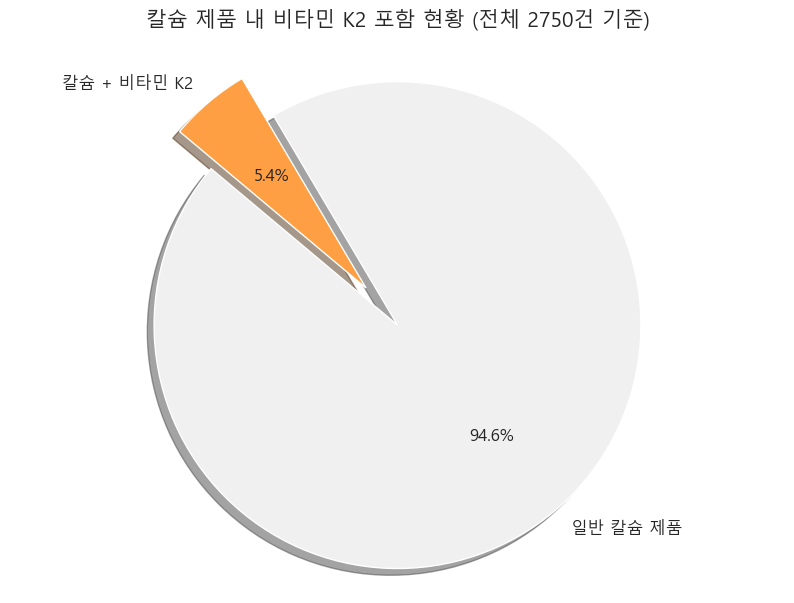

분석 대상(칼슘 제품): 2750개
비타민 K2(메나퀴논) 포함 확인: 148개

[K2 포함 제품 예시]
                                             PRDLST_NM     BSSH_NM
1307                                All in one softgel       (주)서흥
1466                BYHEALTH Glucosamine Liquid(전량수출용)  코스맥스엔비티(주)
1584          CALCIUM CITRATE D3&K2 구연산칼슘 D3&K2(전량수출용)   주식회사 노바렉스
1733             D-Cal Peachy Sachets Liquid Calcium 3  코스맥스엔비티(주)
1814  Daily Children's Multivitamin & Minerals (전량수출용)    우리바이오(주)


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('health_foods.csv', encoding='cp949')

# 2. 칼슘 포함 제품 필터링
# 원재료명(RAWMTRL_NM)에 '칼슘'이 포함된 제품만 먼저 추출
calcium_df = df[df['RAWMTRL_NM'].fillna('').str.contains('칼슘')].copy()

# 3. 비타민 K2 관련 키워드 설정
# 국문 명칭과 학명(메나퀴논)을 모두 포함
k2_keywords = ['비타민 K2', '비타민K2', '메나퀴논', 'MK-7', 'MK7']
k2_pattern = '|'.join(k2_keywords)

# 4. RAWMTRL_NM과 INDIV_RAWMTRL_NM 두 곳에서 모두 검색
# 두 컬럼 중 한 곳이라도 K2 키워드가 있으면 True로 표시합니다.
calcium_df['has_k2'] = (
    calcium_df['RAWMTRL_NM'].fillna('').str.contains(k2_pattern, case=False) | 
    calcium_df['INDIV_RAWMTRL_NM'].fillna('').str.contains(k2_pattern, case=False)
)

# 5. 비중 집계
counts = calcium_df['has_k2'].value_counts()
labels = ['일반 칼슘 제품', '칼슘 + 비타민 K2']
sizes = [counts.get(False, 0), counts.get(True, 0)]
colors = ['#f0f0f0', '#ff9f43'] # K2 제품을 강조하는 오렌지/골드 톤

# 6. 시각화
plt.figure(figsize=(10, 7))
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

# 파이 차트 생성
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors, explode=(0, 0.2), shadow=True, textprops={'fontsize': 12})

plt.title(f'칼슘 제품 내 비타민 K2 포함 현황 (전체 {len(calcium_df)}건 기준)', fontsize=15, pad=20)
plt.axis('equal') 
plt.show()

# 7. 상세 분석 결과 출력
print(f"분석 대상(칼슘 제품): {len(calcium_df)}개")
print(f"비타민 K2(메나퀴논) 포함 확인: {counts.get(True, 0)}개")
if counts.get(True, 0) > 0:
    print("\n[K2 포함 제품 예시]")
    print(calcium_df[calcium_df['has_k2']][['PRDLST_NM', 'BSSH_NM']].head())

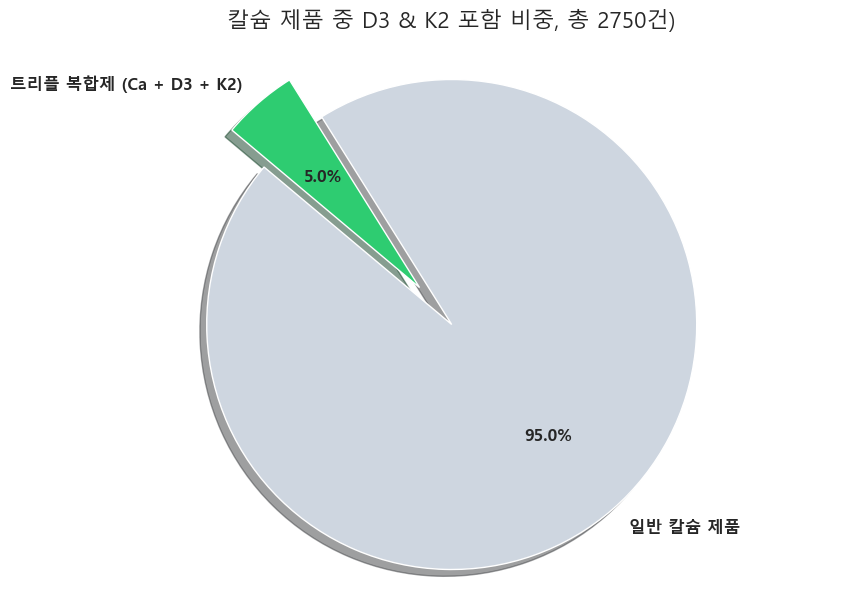

1차 필터링된 칼슘 제품 수: 2750개
INDIV_RAWMTRL_NM에서 D3+K2가 탐지된 제품: 137개

[트리플 복합 제품 예시]
                                             PRDLST_NM     BSSH_NM
1307                                All in one softgel       (주)서흥
1466                BYHEALTH Glucosamine Liquid(전량수출용)  코스맥스엔비티(주)
1584          CALCIUM CITRATE D3&K2 구연산칼슘 D3&K2(전량수출용)   주식회사 노바렉스
1733             D-Cal Peachy Sachets Liquid Calcium 3  코스맥스엔비티(주)
1814  Daily Children's Multivitamin & Minerals (전량수출용)    우리바이오(주)


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('health_foods.csv',encoding='cp949')

# 2. 칼슘 제품 필터링 (RAWMTRL_NM 기준)
# 원재료명에 '칼슘'이 포함된 제품만 1차적으로 추출
calcium_df = df[df['RAWMTRL_NM'].fillna('').str.contains('칼슘')].copy()

# 3. 비타민 D3 및 K2 검색 (INDIV_RAWMTRL_NM 기준)
# D3: 비타민 D, D3, 클로레칼시페롤 등 포함
# K2: 비타민 K2, 메나퀴논, MK-7 등 포함
vit_d_pattern = '비타민 D|비타민D|D3|클로레칼시페롤'
vit_k2_pattern = '비타민 K2|비타민K2|메나퀴논|MK-7|MK7'

def check_premium_ingredients(text):
    text = str(text).upper() # 대소문자 구분 없이 검색
    has_d = pd.Series(text).str.contains(vit_d_pattern, case=False).iloc[0]
    has_k2 = pd.Series(text).str.contains(vit_k2_pattern, case=False).iloc[0]
    
    if has_d and has_k2:
        return '트리플 복합제 (Ca + D3 + K2)'
    else:
        return '일반 칼슘 제품'

# INDIV_RAWMTRL_NM 컬럼을 대상으로 복합 성분 여부 판별
calcium_df['category'] = calcium_df['INDIV_RAWMTRL_NM'].fillna('').apply(check_premium_ingredients)

# 4. 시각화 (Pie Chart)
counts = calcium_df['category'].value_counts()
labels = counts.index
colors = ['#ced6e0', '#2ecc71']

plt.figure(figsize=(10, 7))
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors, explode=(0, 0.2), shadow=True, 
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title(f'칼슘 제품 중 D3 & K2 포함 비중, 총 {len(calcium_df)}건)', 
          fontsize=16, pad=20)
plt.axis('equal')
plt.show()

# 5. 통계 요약 및 리스트 출력
print(f"1차 필터링된 칼슘 제품 수: {len(calcium_df)}개")
print(f"INDIV_RAWMTRL_NM에서 D3+K2가 탐지된 제품: {counts.get('트리플 복합제 (Ca + D3 + K2)', 0)}개")

# 해당되는 제품명 상위 5개 예시 출력
if counts.get('트리플 복합제 (Ca + D3 + K2)', 0) > 0:
    print("\n[트리플 복합 제품 예시]")
    print(calcium_df[calcium_df['category'] == '트리플 복합제 (Ca + D3 + K2)'][['PRDLST_NM', 'BSSH_NM']].head())

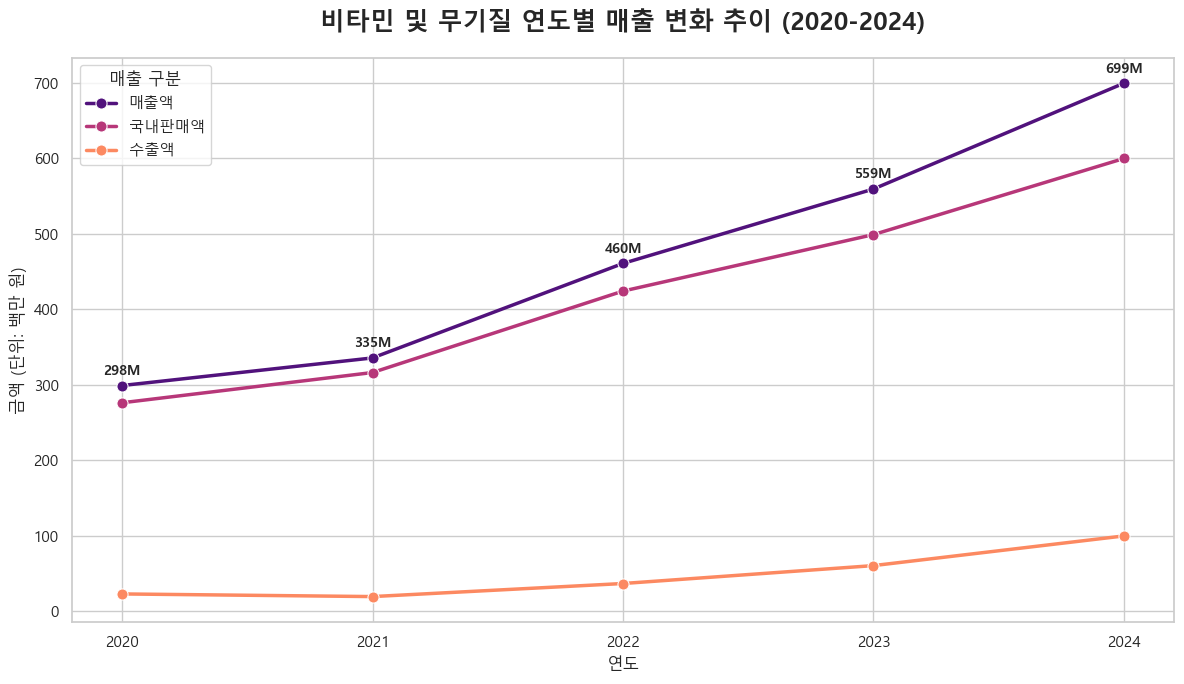

2020년 대비 2024년 전체 매출 성장률: 133.97%


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
# 파일 구조상 0~1행이 헤더 정보이므로 이를 활용해 데이터를 재구성
df = pd.read_csv('비타민_무기질.csv', encoding='cp949', header=None)

# 2. 데이터 재구조화
# 연도 정보와 항목 정보를 추출하여 매칭합니다.
years = [2020, 2021, 2022, 2023, 2024]
sales_types = ['매출액', '국내판매액', '수출액']

# 실제 데이터 값 추출 (3번째 행의 수치 데이터)
data_values = df.iloc[2, 1:].values.astype(float)

# 시각화를 위한 데이터프레임 생성
plot_data = []
idx = 0
for year in years:
    for s_type in sales_types:
        plot_data.append({
            '연도': year,
            '구분': s_type,
            '금액': data_values[idx] / 1000000 # 시각화를 위해 '백만 원' 단위로 변환
        })
        idx += 1

df_final = pd.DataFrame(plot_data)

# 3. 시각화 설정
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 한글 폰트 설정 (Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. 선 그래프 그리기
sns.lineplot(data=df_final, x='연도', y='금액', hue='구분', 
             marker='o', markersize=8, linewidth=2.5, palette='magma')

# 5. 그래프 디테일 추가
plt.title('비타민 및 무기질 연도별 매출 변화 추이 (2020-2024)', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('연도', fontsize=12)
plt.ylabel('금액 (단위: 백만 원)', fontsize=12)
plt.xticks(years) # 연도가 소수점으로 나오지 않게 고정
plt.legend(title='매출 구분', frameon=True)

# 수치 라벨 추가 (매출액 기준)
for x, y in zip(years, df_final[df_final['구분'] == '매출액']['금액']):
    plt.text(x, y + 10, f'{int(y):,}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. 성장률 분석 출력
start_val = df_final[df_final['연도'] == 2020]['금액'].iloc[0]
end_val = df_final[df_final['연도'] == 2024]['금액'].iloc[0]
growth_rate = ((end_val - start_val) / start_val) * 100

print(f"2020년 대비 2024년 전체 매출 성장률: {growth_rate:.2f}%")

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_9952\3936027467.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='매출액', y='품목', data=df_top5, palette=colors)


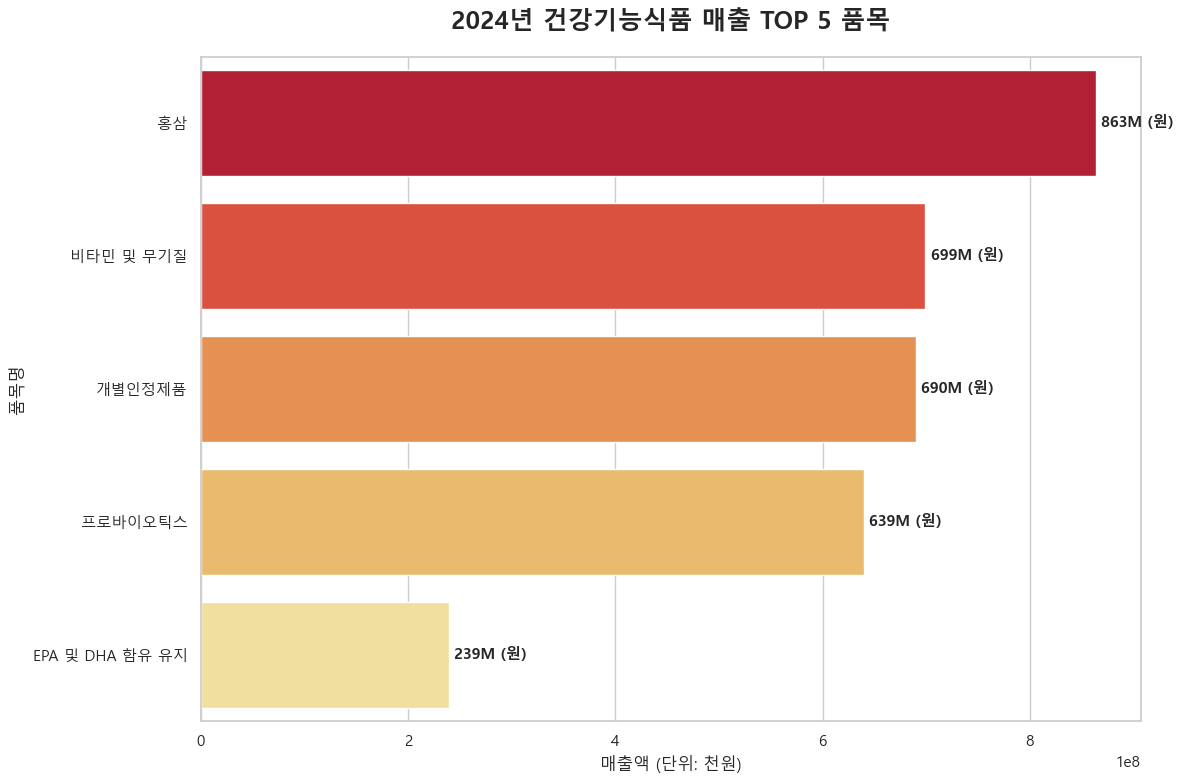

--- 2024년 매출 TOP 5 리스트 ---
             품목       매출액
             홍삼 863554248
      비타민 및 무기질 699202611
         개별인정제품 690286063
        프로바이오틱스 639748886
EPA 및 DHA 함유 유지 239104798


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
try:
    df = pd.read_csv('건강기능식품_매출액__국내_판매액_및_수출액.csv', encoding='cp949', skiprows=1)
except:
    df = pd.read_csv('건강기능식품_매출액__국내_판매액_및_수출액.csv', encoding='utf-8', skiprows=1)

# 2. 컬럼명 정제
df.columns = ['품목', '매출액', '국내판매액', '수출액']

# 3. 데이터 전처리
# '계' 항목은 개별 품목이 아니므로 제외하고, 매출액 기준으로 내림차순 정렬
df_items = df[df['품목'] != '계'].copy()
df_items['매출액'] = pd.to_numeric(df_items['매출액'], errors='coerce') # 숫자형 변환
df_top5 = df_items.sort_values(by='매출액', ascending=False).head(5)

# 4. 시각화 설정
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 5. 막대 그래프 생성
colors = sns.color_palette('YlOrRd_r', n_colors=5) # 매출이 높을수록 진한 색상
ax = sns.barplot(x='매출액', y='품목', data=df_top5, palette=colors)

# 6. 그래프 디테일 추가
plt.title('2024년 건강기능식품 매출 TOP 5 품목', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('매출액 (단위: 천원)', fontsize=12)
plt.ylabel('품목명', fontsize=12)

# 막대 끝에 실제 매출액 수치 표시
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 5000000, p.get_y() + p.get_height()/2, 
             f'{int(width/1000000):,}M (원)', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 7. 텍스트 요약 출력
print("--- 2024년 매출 TOP 5 리스트 ---")
print(df_top5[['품목', '매출액']].to_string(index=False))

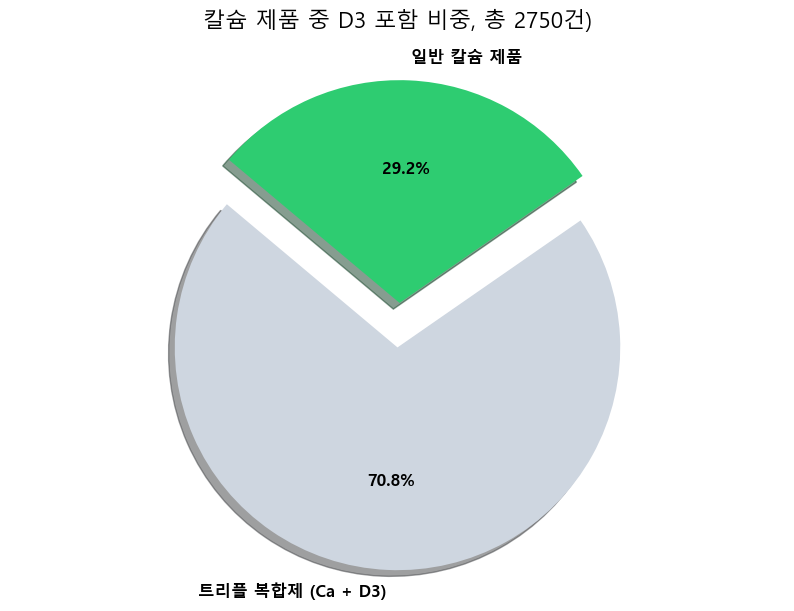

1차 필터링된 칼슘 제품 수: 2750개
INDIV_RAWMTRL_NM에서 D3가 탐지된 제품: 0개

[트리플 복합 제품 예시]
           PRDLST_NM         BSSH_NM
57             + 뼈건강       (주)한풍네이처팜
65   100% 식물성 프로틴 케어  콜마비앤에이치(주)음성공장
503     2030 에너지 올인원  광동헬스바이오(주) 2공장
507         211프로틴코어              코뉴
510            2875탁       (주)메디바이오랩


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('health_foods.csv',encoding='cp949')

# 2. 칼슘 제품 필터링 (RAWMTRL_NM 기준)
# 원재료명에 '칼슘'이 포함된 제품만 1차적으로 추출
calcium_df = df[df['RAWMTRL_NM'].fillna('').str.contains('칼슘')].copy()

# 3. 비타민 D3 및 K2 검색 (INDIV_RAWMTRL_NM 기준)
# D3: 비타민 D, D3, 클로레칼시페롤 등 포함
# K2: 비타민 K2, 메나퀴논, MK-7 등 포함
vit_d_pattern = '비타민 D|비타민D|D3|클로레칼시페롤'
# vit_k2_pattern = '비타민 K2|비타민K2|메나퀴논|MK-7|MK7'

def check_premium_ingredients(text):
    text = str(text).upper() # 대소문자 구분 없이 검색
    has_d = pd.Series(text).str.contains(vit_d_pattern, case=False).iloc[0]
    # has_k2 = pd.Series(text).str.contains(vit_k2_pattern, case=False).iloc[0]
    
    if has_d:
        return '트리플 복합제 (Ca + D3)'
    else:
        return '일반 칼슘 제품'

# INDIV_RAWMTRL_NM 컬럼을 대상으로 복합 성분 여부 판별
calcium_df['category'] = calcium_df['INDIV_RAWMTRL_NM'].fillna('').apply(check_premium_ingredients)

# 4. 시각화 (Pie Chart)
counts = calcium_df['category'].value_counts()
labels = counts.index
colors = ['#ced6e0', '#2ecc71']

plt.figure(figsize=(10, 7))
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors, explode=(0, 0.2), shadow=True, 
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title(f'칼슘 제품 중 D3 포함 비중, 총 {len(calcium_df)}건)', 
          fontsize=16, pad=20)
plt.axis('equal')
plt.show()

# 5. 통계 요약 및 리스트 출력
print(f"1차 필터링된 칼슘 제품 수: {len(calcium_df)}개")
print(f"INDIV_RAWMTRL_NM에서 D3가 탐지된 제품: {counts.get('복합제 (Ca + D3)', 0)}개")

# 해당되는 제품명 상위 5개 예시 출력
if counts.get('트리플 복합제 (Ca + D3)', 0) > 0:
    print("\n[트리플 복합 제품 예시]")
    print(calcium_df[calcium_df['category'] == '트리플 복합제 (Ca + D3)'][['PRDLST_NM', 'BSSH_NM']].head())

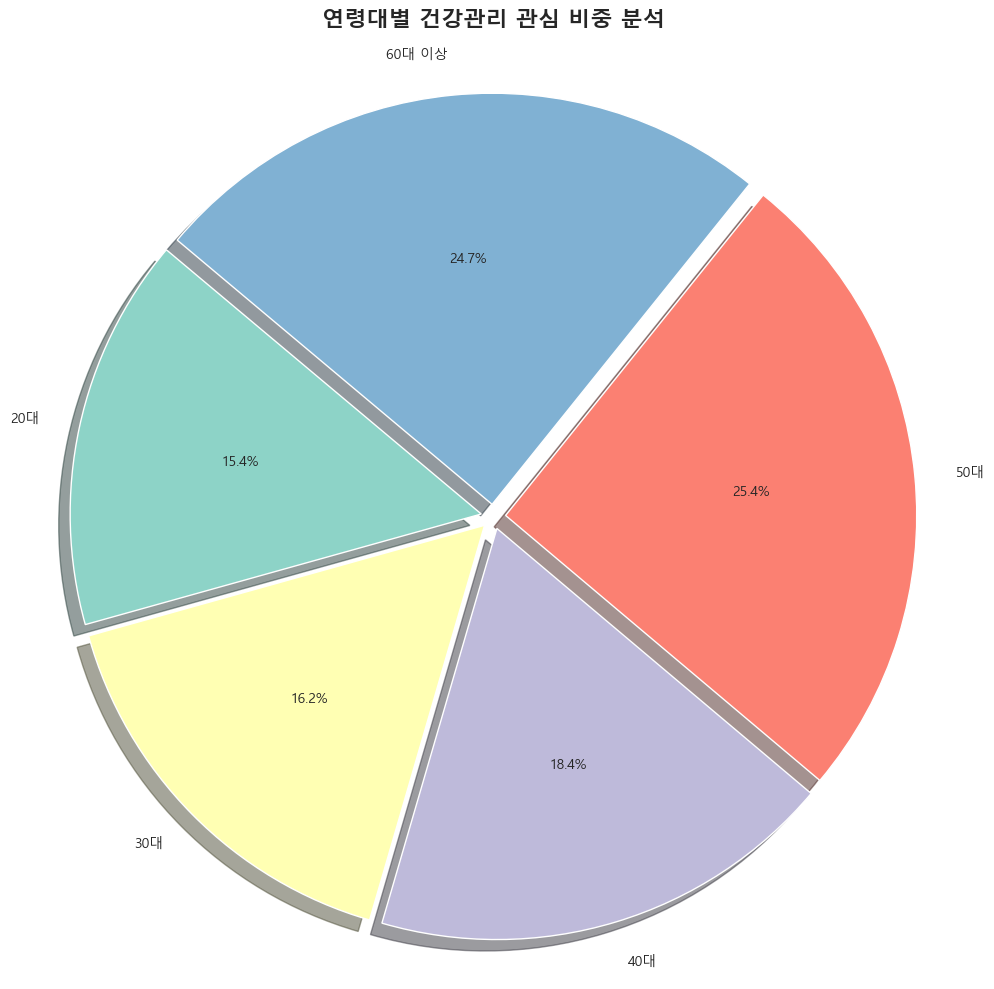

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('연령대별_건강관리관심도.csv', encoding='cp949')

# 2. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 3. 데이터 추출 (열 번호 기준: 0부터 시작)
# 첫 번째 열(index 0): 연령대
# 네 번째 열(index 4): 관심있음 비중
labels = df.iloc[:, 0]
sizes = df.iloc[:, 4]

# 4. 파이 차트 시각화 설정
plt.figure(figsize=(10, 10))
colors = plt.cm.Set3.colors
explode = [0.03] * len(labels) # 각 조각을 살짝 분리

# 5. 파이 차트 그리기
plt.pie(sizes, 
        explode=explode, 
        labels=labels, 
        autopct='%1.1f%%',   # 소수점 첫째 자리까지 비중 표시
        startangle=140,      # 시작 각도 조정
        shadow=True,         # 그림자 효과로 입체감 부여
        colors=colors)

# 6. 제목 및 레이아웃 설정
plt.title('연령대별 건강관리 관심도 분석', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal') # 원의 형태를 정원으로 유지

plt.tight_layout()
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_11448\2979114225.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette=colors)


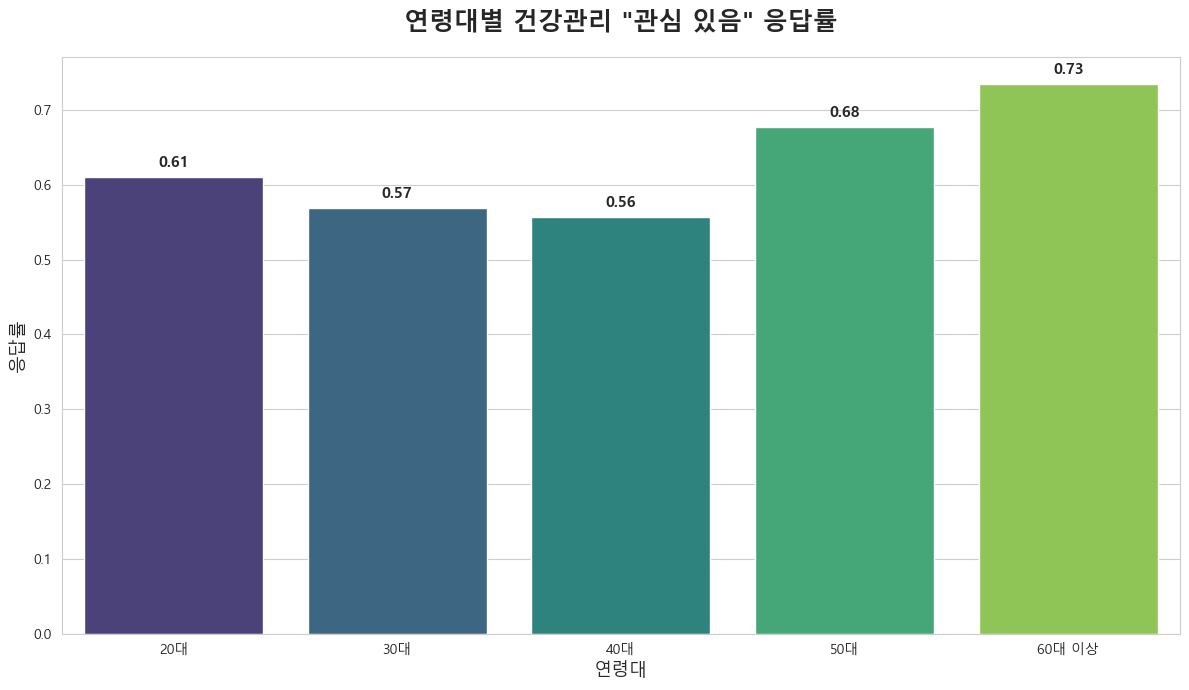

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
df = pd.read_csv('연령대별_건강관리관심도.csv', encoding='cp949')

# 2. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 3. 데이터 준비
# 첫 번째 열(index 0): 연령대
# 네 번째 열(index 4): 관심 있음 응답 수
labels = df.iloc[:, 0]
counts = df.iloc[:, 4] / df.iloc[:, 1]

# 4. 시각화 설정 (막대 그래프)
plt.figure(figsize=(12, 7))
colors = sns.color_palette("viridis", len(labels)) # 가독성 좋은 컬러 팔레트

ax = sns.barplot(x=labels, y=counts, palette=colors)

# 5. 그래프 꾸미기
plt.title('연령대별 건강관리 "관심 있음" 응답률', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('연령대', fontsize=13)
plt.ylabel('응답률', fontsize=13)

# 막대 위에 실제 수치 표시
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv('health_foods.csv', encoding='cp949')

# 2. 칼슘 제품 1차 필터링
calcium_df = df[df['RAWMTRL_NM'].fillna('').str.contains('칼슘')].copy()

# 3. 비타민 D3 및 K2 검색 패턴 설정
vit_d_pattern = '비타민 D|비타민D|D3|클로레칼시페롤'
vit_k2_pattern = '비타민 K2|비타민K2|메나퀴논|MK-7|MK7'

# 4. 트리플 복합제(Ca + D3 + K2) 필터링 함수
def is_triple_complex(row):
    # 원재료명 또는 개별인정형 원재료명 컬럼에서 검색
    text = str(row['INDIV_RAWMTRL_NM'])
    text = text.upper()
    
    # 칼슘은 이미 위에서 필터링되었으므로 D와 K2 존재 여부만 확인
    has_d = pd.Series(text).str.contains(vit_d_pattern, case=False).iloc[0]
    has_k2 = pd.Series(text).str.contains(vit_k2_pattern, case=False).iloc[0]
    
    return has_d and has_k2

# 조건에 맞는 데이터만 추출
triple_complex_df = calcium_df[calcium_df.apply(is_triple_complex, axis=1)].copy()

# 5. 필요한 열만 선택 (품목명, 회사명, 제형)
# PRDLST_NM: 품목명, BSSH_NM: 회사명, PRDT_SHAP_CD_NM: 제형
result_df = triple_complex_df[['PRDLST_NM', 'BSSH_NM', 'PRDT_SHAP_CD_NM']]

# 6. CSV 파일로 저장
output_filename = 'calcium_d3_k2_products.csv'
result_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"추출 완료! 총 {len(result_df)}개의 제품이 '{output_filename}'으로 저장되었습니다.")

# 데이터 확인을 위한 상위 5개 출력
print("\n[추출된 제품 리스트 상위 5개]")
print(result_df.head())

추출 완료! 총 137개의 제품이 'calcium_d3_k2_products.csv'으로 저장되었습니다.

[추출된 제품 리스트 상위 5개]
                                             PRDLST_NM     BSSH_NM  \
1307                                All in one softgel       (주)서흥   
1466                BYHEALTH Glucosamine Liquid(전량수출용)  코스맥스엔비티(주)   
1584          CALCIUM CITRATE D3&K2 구연산칼슘 D3&K2(전량수출용)   주식회사 노바렉스   
1733             D-Cal Peachy Sachets Liquid Calcium 3  코스맥스엔비티(주)   
1814  Daily Children's Multivitamin & Minerals (전량수출용)    우리바이오(주)   

     PRDT_SHAP_CD_NM  
1307              캡슐  
1466              액상  
1584               정  
1733              액상  
1814              분말  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('health_foods.csv',encoding='cp949')

# 2. 칼슘 제품 필터링 (RAWMTRL_NM 기준)
# 원재료명에 '칼슘'이 포함된 제품만 1차적으로 추출
calcium_df = df[df['RAWMTRL_NM'].fillna('').str.contains('칼슘')].copy()

# 3. 비타민 D3 및 K2 검색 (INDIV_RAWMTRL_NM 기준)
# D3: 비타민 D, D3, 클로레칼시페롤 등 포함
# K2: 비타민 K2, 메나퀴논, MK-7 등 포함
vit_d_pattern = '비타민 D|비타민D|D3|클로레칼시페롤'
vit_k2_pattern = '비타민 K2|비타민K2|메나퀴논|MK-7|MK7'

def check_premium_ingredients(text):
    text = str(text).upper() # 대소문자 구분 없이 검색
    has_d = pd.Series(text).str.contains(vit_d_pattern, case=False).iloc[0]
    has_k2 = pd.Series(text).str.contains(vit_k2_pattern, case=False).iloc[0]
    
    if has_d and has_k2:
        return '트리플 복합제 (Ca + D3 + K2)'
    else:
        return '일반 칼슘 제품'

# INDIV_RAWMTRL_NM 컬럼을 대상으로 복합 성분 여부 판별
calcium_df['category'] = calcium_df['INDIV_RAWMTRL_NM'].fillna('').apply(check_premium_ingredients)

# 4. 시각화 (Pie Chart)
counts = calcium_df['category'].value_counts()
labels = counts.index
colors = ['#ced6e0', '#2ecc71']

plt.figure(figsize=(10, 7))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors, explode=(0, 0.2), shadow=True, 
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title(f'칼슘 제품 중 D3 & K2 포함 비중, 총 {len(calcium_df)}건)', 
          fontsize=16, pad=20)
plt.axis('equal')
plt.show()

# 5. 통계 요약 및 리스트 출력
print(f"1차 필터링된 칼슘 제품 수: {len(calcium_df)}개")
print(f"INDIV_RAWMTRL_NM에서 D3+K2가 탐지된 제품: {counts.get('트리플 복합제 (Ca + D3 + K2)', 0)}개")

# 해당되는 제품명 상위 5개 예시 출력
if counts.get('트리플 복합제 (Ca + D3 + K2)', 0) > 0:
    print("\n[트리플 복합 제품 예시]")
    print(calcium_df[calcium_df['category'] == '트리플 복합제 (Ca + D3 + K2)'][['PRDLST_NM', 'BSSH_NM']].head())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 데이터 불러오기
df = pd.read_csv('영양소 함량.xlsx - Sheet1.csv')

# 2. 단위 제거 및 수치형 변환 함수
def clean_unit(text):
    if pd.isna(text): return 0
    # 숫자와 소수점만 추출
    value = re.findall(r"[-+]?\d*\.\d+|\d+", str(text))
    return float(value[0]) if value else 0

# 권장량과 함량 컬럼 수치화
df['권장량_num'] = df['권장량'].apply(clean_unit)
df['함량_num'] = df['함량'].apply(clean_unit)

# 3. 권장량 대비 충족률(%) 계산
df['충족률'] = (df['함량_num'] / df['권장량_num']) * 100

# 4. 시각화 설정
plt.figure(figsize=(12, 8))
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 충족률 기준 막대 그래프 생성
colors = sns.color_palette("husl", len(df))
ax = sns.barplot(x='충족률', y='영양소', data=df, palette=colors)

# 5. 그래프 꾸미기
plt.title('주요 식품 1회 섭취 시 영양소 권장량 대비 충족률 (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('권장량 대비 함량 비율 (%)', fontsize=12)
plt.ylabel('영양소 및 주요 식품', fontsize=12)

# Y축 레이블에 식품명
new_labels = [f"{row['영양소']} ({row['주요식품']})" for _, row in df.iterrows()]
ax.set_yticklabels(new_labels)

# 100% 기준선 표시 (권장량 도달 지점)
plt.axvline(x=100, color='red', linestyle='--', linewidth=1.5, label='100% 권장량')
plt.legend()

# 막대 끝에 실제 퍼센트 수치 표시
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 1, p.get_y() + p.get_height()/2), 
                va='center', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_11448\2622764042.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='충족률', y='영양소', data=df, palette=colors)
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_11448\2622764042.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)


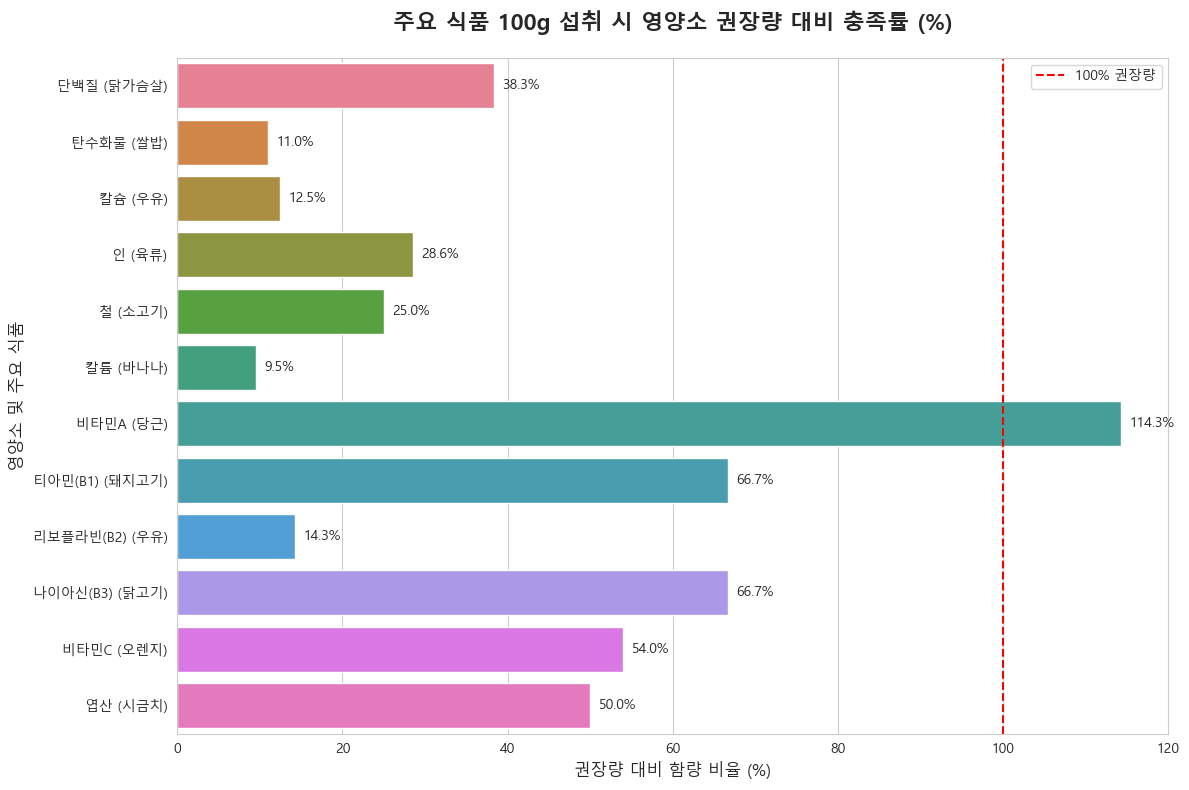

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 데이터 불러오기
df = pd.read_csv('영양소 함량.csv')

# 2. 단위 제거 및 수치형 변환 함수
def clean_unit(text):
    if pd.isna(text): return 0
    # 숫자와 소수점만 추출
    value = re.findall(r"[-+]?\d*\.\d+|\d+", str(text))
    return float(value[0]) if value else 0

# 권장량과 함량 컬럼 수치화
df['권장량_num'] = df['권장량'].apply(clean_unit)
df['함량_num'] = df['함량'].apply(clean_unit)

# 3. 권장량 대비 충족률(%) 계산
df['충족률'] = (df['함량_num'] / df['권장량_num']) * 100

# 4. 시각화 설정
plt.figure(figsize=(12, 8))
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 충족률 기준 막대 그래프 생성
colors = sns.color_palette("husl", len(df))
ax = sns.barplot(x='충족률', y='영양소', data=df, palette=colors)

# 5. 그래프 꾸미기
plt.title('주요 식품 100g 섭취 시 영양소 권장량 대비 충족률 (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('권장량 대비 함량 비율 (%)', fontsize=12)
plt.ylabel('영양소 및 주요 식품', fontsize=12)

# Y축 레이블에 식품명
new_labels = [f"{row['영양소']} ({row['주요식품']})" for _, row in df.iterrows()]
ax.set_yticklabels(new_labels)

# 100% 기준선 표시 (권장량 도달 지점)
plt.axvline(x=100, color='red', linestyle='--', linewidth=1.5, label='100% 권장량')
plt.legend()

# 막대 끝에 실제 퍼센트 수치 표시
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 1, p.get_y() + p.get_height()/2), 
                va='center', fontsize=10)

plt.tight_layout()
plt.show()